# Chương 3 — Text Classification & Sentiment Analysis
Notebook này được thiết kế để sinh viên thực hành xây dựng và so sánh nhiều hệ thống phân loại văn bản:

1. **Rule-based baseline**
2. **TF-IDF + Multinomial Naive Bayes**
3. **TF-IDF + Logistic Regression**
4. **TF-IDF + Linear SVM**
5. **Decision Tree / Random Forest** ở mức tham khảo
6. **Lexicon-based Sentiment Analysis**
7. **PhoBERT / ViSoBERT** ở mức mở rộng

### Mục tiêu
Sinh viên phải trả lời được:

- Văn bản được biến thành vector như thế nào?
- Vì sao TF-IDF thường mạnh hơn Bag of Words thô?
- Naive Bayes, Logistic Regression và SVM khác nhau ra sao?
- Accuracy có đủ để đánh giá mô hình không?
- Khi dữ liệu mất cân bằng nên dùng metric nào?
- Vì sao sentiment analysis khó với phủ định, sarcasm, emoji và domain shift?
- Mô hình pretrained cải thiện điểm gì và đánh đổi điều gì?

> Notebook có dữ liệu demo nhỏ nhúng sẵn để chạy độc lập. Tuy nhiên, khi thực hiện bài thực hành sinh viên cần thay bằng UIT-VSFC, UIT-VSMEC hoặc dữ liệu tương đương.

# 0. Chuẩn bị môi trường

Notebook dùng các thư viện phổ biến:
- pandas
- numpy
- scikit-learn
- matplotlib


In [344]:
import re
import time
import math
import random
import unicodedata
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer


from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, HashingVectorizer
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
print("Environment ready.")

Environment ready.


# 1. Dữ liệu mẫu

Ta dùng một dataset nhỏ gồm:
- `text`: câu tiếng Việt
- `sentiment`: `positive / negative / neutral`
- `topic`: `teaching / facility / administration / technology`

Mục đích:
- sentiment → bài toán **multiclass classification**
- topic → một bài toán classification khác trên cùng văn bản
- về sau có thể mở rộng thành multilabel.

In [345]:
positive_templates = [
    ("Giảng viên dạy rất dễ hiểu và nhiệt tình", "teaching"),
    ("Bài giảng rõ ràng, ví dụ thực tế rất hữu ích", "teaching"),
    ("Phòng học sạch sẽ và máy lạnh hoạt động tốt", "facility"),
    ("Thư viện rộng, yên tĩnh và có nhiều tài liệu", "facility"),
    ("Phòng đào tạo hỗ trợ sinh viên rất nhanh", "administration"),
    ("Thủ tục đăng ký môn học khá thuận tiện", "administration"),
    ("Hệ thống học trực tuyến chạy ổn định và dễ sử dụng", "technology"),
    ("Website mới nhanh hơn và ít lỗi hơn trước", "technology"),
    ("Mình rất hài lòng với môn học này", "teaching"),
    ("Wifi trong trường hôm nay rất tốt", "technology"),
]

negative_templates = [
    ("Giảng viên giảng quá nhanh nên tôi không theo kịp", "teaching"),
    ("Bài tập quá nhiều nhưng hướng dẫn chưa rõ", "teaching"),
    ("Phòng học nóng và máy lạnh thường xuyên hỏng", "facility"),
    ("Nhà vệ sinh chưa sạch và thiếu giấy", "facility"),
    ("Phòng đào tạo xử lý hồ sơ quá chậm", "administration"),
    ("Thủ tục đăng ký rườm rà và mất nhiều thời gian", "administration"),
    ("Website thường xuyên lỗi khi đăng ký môn học", "technology"),
    ("Hệ thống học trực tuyến rất chậm và hay bị treo", "technology"),
    ("Tôi không hài lòng với cách tổ chức lớp", "teaching"),
    ("Wifi yếu, kết nối chập chờn cả buổi", "technology"),
]

neutral_templates = [
    ("Môn học có ba tín chỉ và học vào thứ hai", "teaching"),
    ("Giảng viên đăng tài liệu lên hệ thống mỗi tuần", "teaching"),
    ("Phòng học nằm ở tầng ba của tòa nhà", "facility"),
    ("Thư viện mở cửa từ sáng đến tối", "facility"),
    ("Phòng đào tạo tiếp nhận hồ sơ tại quầy số hai", "administration"),
    ("Sinh viên đăng ký môn học qua cổng thông tin", "administration"),
    ("Hệ thống học trực tuyến có phiên bản web", "technology"),
    ("Website yêu cầu đăng nhập bằng tài khoản sinh viên", "technology"),
    ("Lớp có khoảng bốn mươi sinh viên", "teaching"),
    ("Trường có nhiều điểm phát wifi", "technology"),
]

augment_prefix = [
    "", "Theo mình, ", "Cá nhân mình thấy ", "Hôm nay ", "Trong học kỳ này, "
]
augment_suffix = [
    "", ".", "!", " :)", " 👍", " 😐"
]

rows = []
for sentiment, templates in [
    ("positive", positive_templates),
    ("negative", negative_templates),
    ("neutral", neutral_templates),
]:
    for base, topic in templates:
        for i in range(4):
            text = random.choice(augment_prefix) + base + random.choice(augment_suffix)
            rows.append((text, sentiment, topic))

df = pd.DataFrame(rows, columns=["text", "sentiment", "topic"])
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(df.shape)
display(df.head(10))
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())
print("\nTopic distribution:")
print(df["topic"].value_counts())

(120, 3)


,text,sentiment,topic
0,Cá nhân mình thấy Bài tập quá nhiều nhưng hướng dẫn chưa rõ,negative,teaching
1,Cá nhân mình thấy Bài tập quá nhiều nhưng hướng dẫn chưa rõ,negative,teaching
2,"Trong học kỳ này, Bài giảng rõ ràng, ví dụ thực tế rất hữu ích",positive,teaching
3,Cá nhân mình thấy Nhà vệ sinh chưa sạch và thiếu giấy 😐,negative,facility
4,Cá nhân mình thấy Hệ thống học trực tuyến chạy ổn định và dễ sử dụng 😐,positive,technology
5,Hôm nay Website thường xuyên lỗi khi đăng ký môn học 👍,negative,technology
6,Cá nhân mình thấy Tôi không hài lòng với cách tổ chức lớp :),negative,teaching
7,"Trong học kỳ này, Phòng học sạch sẽ và máy lạnh hoạt động tốt.",positive,facility
8,"Theo mình, Giảng viên giảng quá nhanh nên tôi không theo kịp.",negative,teaching
9,"Theo mình, Hệ thống học trực tuyến có phiên bản web 👍",neutral,technology



Sentiment distribution:
sentiment
negative    40
positive    40
neutral     40
Name: count, dtype: int64

Topic distribution:
topic
teaching          36
technology        36
facility          24
administration    24
Name: count, dtype: int64


## Task 1 — Bài toán phân loại

### Code mẫu
- sentiment: **multiclass** với 3 nhãn.
- topic: **multiclass** với 4 nhãn.

### Yêu cầu sinh viên
1. Chuyển một phần dữ liệu thành **binary classification**: positive vs non-positive.
2. Thiết kế một ví dụ **multilabel**: một phản hồi có thể vừa nói về `teaching` vừa nói về `facility`.
3. Đề xuất một taxonomy **hierarchical classification**:
   - `academic`
     - teaching
     - curriculum
   - `service`
     - administration
     - facility
4. Giải thích khác biệt giữa:
   - text classification,
   - sequence labeling.

### TODO

In [346]:
df = pd.read_csv("synthetic_train.csv").rename(columns={"sentence": "text"})
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

VIET_DIACRITICS = set(
    "ăâđêôơưĂÂĐÊÔƠƯ"
    "áàảãạấầẩẫậắằẳẵặéèẻẽẹếềểễệíìỉĩịóòỏõọốồổỗộớờởỡợúùủũụứừửữựýỳỷỹỵ"
    "ÁÀẢÃẠẤẦẨẪẬẮẰẲẴẶÉÈẺẼẸẾỀỂỄỆÍÌỈĨỊÓÒỎÕỌỐỒỔỖỘỚỜỞỠỢÚÙỦŨỤỨỪỬỮỰÝỲỶỸỴ"
)

def is_vietnamese(text):
    return any(c in VIET_DIACRITICS for c in text)

#Xóa các câu tiếng anh
n_before = len(df)
df["_is_vietnamese"] = df["text"].apply(is_vietnamese)
removed = df.loc[~df["_is_vietnamese"], "text"]

df = df[df["_is_vietnamese"]].drop(columns=["_is_vietnamese"]).reset_index(drop=True)
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())
print("\nTopic distribution:")
print(df["topic"].value_counts())


Sentiment distribution:
sentiment
negative    2711
positive    2709
neutral     2409
Name: count, dtype: int64

Topic distribution:
topic
others        2059
lecturer      2026
curriculum    1925
facility      1819
Name: count, dtype: int64


In [347]:
try:
    from english_words import get_english_words_set
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "english-words"])
    from english_words import get_english_words_set

EN_DICT = get_english_words_set(["web2"], lower=True)

# Candidate: từ tiếng Anh xuất hiện (ASCII, length>=4) đối chiếu với từ điển
candidate_tokens = set()
for t in df["text"]:
    for w in re.findall(r"[a-zA-Z]+", t.lower()):
        if len(w) >= 4 and w in EN_DICT:
            candidate_tokens.add(w)
print(f"Số token ứng viên (khớp từ điển tiếng Anh, chưa lọc false positive): {len(candidate_tokens)}")

# Danh sách được chọn lọc THỦ CÔNG sau khi đối chiếu từng từ với câu gốc trong corpus
# (chỉ giữ các từ THẬT SỰ là code-switching / từ mượn tiếng Anh)
CURATED_ENGLISH_LOANWORDS = {
    "logic", "photocopy", "stress", "tress", "karaoke", "tennis", "video",
    "marketing", "slide", "yoga", "feedback", "visa", "deadline", "camera",
    "game", "toilet", "canteen", "merger", "view", "critical", "thinking",
    "chat", "public", "laser", "software", "sofa", "active", "contact",
    "locker", "scan", "problem", "bbq",
}
false_positives = candidate_tokens - CURATED_ENGLISH_LOANWORDS
print(f"Số token bị loại khỏi danh sách vì là từ tiếng Việt hợp lệ (false positive): {len(false_positives)}")
print("Ví dụ false positive đã giữ lại (KHÔNG xóa):", sorted(false_positives)[:15])

def remove_english_loanwords(text):
    def is_loanword(tok):
        core = re.sub(r"[^a-zA-Z]", "", tok.lower())
        return core in CURATED_ENGLISH_LOANWORDS and core != ""
    return " ".join(tok for tok in text.split() if not is_loanword(tok))

before_examples = df.loc[df["text"].str.lower().str.contains(
    "|".join(rf"\b{w}\b" for w in CURATED_ENGLISH_LOANWORDS)), "text"].head(5)
print("\nVí dụ TRƯỚC khi xóa từ mượn:")
for t in before_examples:
    print(" -", t)

df["text"] = df["text"].apply(remove_english_loanwords)
df["text"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()

print("\nVí dụ SAU khi xóa từ mượn (cùng các câu trên):")
for t in before_examples:
    print(" -", remove_english_loanwords(t))

Số token ứng viên (khớp từ điển tiếng Anh, chưa lọc false positive): 49
Số token bị loại khỏi danh sách vì là từ tiếng Việt hợp lệ (false positive): 18
Ví dụ false positive đã giữ lại (KHÔNG xóa): ['chia', 'dang', 'dung', 'facility', 'hung', 'khan', 'lung', 'mang', 'mong', 'quan', 'quay', 'sang', 'sinh', 'song', 'sung']

Ví dụ TRƯỚC khi xóa từ mượn:
 - Chương trình đào tạo giúp tôi nâng cao kỹ năng tư duy logic và phản biện.
 - Merger nhà ga với phòng học làm giảm chất lượng học tập.
 - Anh ấy có trí tuệ và tư duy logic tốt.
 - Tôi rất thích việc được học trực tuyến ở những khóa học thông qua video và livestream.
 - Thầy sử dụng những hình ảnh và video để giải thích các khái niệm phức tạp một cách dễ hiểu.

Ví dụ SAU khi xóa từ mượn (cùng các câu trên):
 - Chương trình đào tạo giúp tôi nâng cao kỹ năng tư duy và phản biện.
 - nhà ga với phòng học làm giảm chất lượng học tập.
 - Anh ấy có trí tuệ và tư duy tốt.
 - Tôi rất thích việc được học trực tuyến ở những khóa học thông qua và live

In [348]:
# 1. Binary sentiment
df["binary_sentiment"] = df["sentiment"].apply(
    lambda x: "positive" if x == "positive" else "non_positive"
)
display(df[["text", "sentiment", "binary_sentiment"]].head())
print(df["binary_sentiment"].value_counts())

# 2. Ví dụ multilabel
TOPIC_KEYWORDS = {
    "lecturer": ["giảng viên", "thầy", "cô ", "giáo viên"],
    "facility": ["phòng", "thư viện", "cơ sở vật chất", "wifi", "máy lạnh",
                 "nhà vệ sinh", "ký túc xá", "trang thiết bị"],
    "curriculum": ["chương trình", "môn học", "giáo trình", "học phần", "bài giảng"],
}

def matched_topics(text):
    t = text.lower()
    return [topic for topic, words in TOPIC_KEYWORDS.items() if any(w in t for w in words)]

df["_matched_topics"] = df["text"].apply(matched_topics)
multilabel_candidates = df[df["_matched_topics"].apply(len) >= 2].copy()
print(f"Tìm được {len(multilabel_candidates)} câu THẬT trong corpus đề cập >=2 topic.")

multilabel_examples = multilabel_candidates[["text", "topic", "_matched_topics"]].rename(
    columns={"topic": "topic_goc_trong_csv", "_matched_topics": "labels_suy_ra_tu_tu_khoa"}
).head(5).reset_index(drop=True)
display(multilabel_examples)
df = df.drop(columns=["_matched_topics"])

# 3. Taxonomy hierarchical
hierarchy = {
    "academic": ["curriculum", "lecturer"],
    "service": ["facility"],
    "other": ["others"],
}
print("Hierarchical taxonomy:")
for parent, children in hierarchy.items():
    print(f"  {parent}: {children}")

,text,sentiment,binary_sentiment
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đảm bảo được chất lượng sửa chữa thiết bị.,negative,non_positive
1,Phương pháp giảng dạy phù hợp với các đối tượng sinh viên khác nhau.,neutral,non_positive
2,Chương trình học giúp tôi trở thành một chuyên gia trong lĩnh vực của mình.,positive,positive
3,Tôi nghĩ rằng chương trình đào tạo có thể có thêm các môn học về lịch sử và văn hóa để sinh viên hiểu rõ hơn về đất nước và con người Việt Nam,neutral,non_positive
4,Chị ấy luôn tỉ mỉ trong công việc.,neutral,non_positive


binary_sentiment
non_positive    5120
positive        2709
Name: count, dtype: int64
Tìm được 193 câu THẬT trong corpus đề cập >=2 topic.


,text,topic_goc_trong_csv,labels_suy_ra_tu_tu_khoa
0,Thầy cô không dạy đầy đủ nội dung của môn học.,lecturer,"[lecturer, curriculum]"
1,Chương trình học thiếu sự đưa ra các bài giảng viên chuyên nghiệp và đầy đủ thông tin.,curriculum,"[lecturer, curriculum]"
2,"Em rất cảm kích sự đam mê của thầy với môn học, giúp em có thêm động lực học tập.",lecturer,"[lecturer, curriculum]"
3,"Chương trình đào tạo tuyệt vời, chúng tôi đã học được rất nhiều từ những giảng viên tận tâm.",curriculum,"[lecturer, curriculum]"
4,"Quá nhiều chương trình giảng dạy được tổ chức trên mạng, không có sự tương tác giữa sinh viên và giảng viên.",curriculum,"[lecturer, curriculum]"


Hierarchical taxonomy:
  academic: ['curriculum', 'lecturer']
  service: ['facility']
  other: ['others']


**4. Text classification vs. sequence labeling**

- **Text classification**: gán **một (hoặc vài) nhãn cho cả câu/văn bản**, ví dụ
  `sentiment` hay `topic` ở trên — input là toàn câu, output là 1 nhãn (hoặc 1
  tập nhãn cho multilabel). Không quan tâm vị trí từ nào gây ra nhãn đó.
- **Sequence labeling**: gán **một nhãn cho từng token** trong câu (NER, POS
  tagging, hay aspect-term extraction). Ví dụ với câu "Giảng viên dạy rất
  nhiệt tình nhưng phòng học quá nóng", sequence labeling sẽ đánh dấu
  `giảng viên` = ASPECT-LECTURER, `phòng học` = ASPECT-FACILITY — output có
  cùng độ dài với input, mỗi token có nhãn.
- Aspect-based sentiment (mục 15) thường **kết hợp cả hai**: sequence labeling
  để tìm aspect span, rồi text classification để gán sentiment cho từng span.

# 2. Tiền xử lý tối thiểu

Với các mô hình truyền thống, ta thường:
- Unicode normalization
- lowercase
- chuẩn hóa khoảng trắng

Không nên xóa quá nhiều thông tin khi làm sentiment:
- dấu chấm than,
- emoji,
- từ phủ định
có thể mang tín hiệu cảm xúc.

In [349]:
def normalize_text(text):
    text = unicodedata.normalize("NFC", str(text))
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_norm"] = df["text"].map(normalize_text)
display(df[["text", "text_norm"]].head())

,text,text_norm
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đảm bảo được chất lượng sửa chữa thiết bị.,đội ngũ bảo trì quá thưa thớt dẫn đến không đảm bảo được chất lượng sửa chữa thiết bị.
1,Phương pháp giảng dạy phù hợp với các đối tượng sinh viên khác nhau.,phương pháp giảng dạy phù hợp với các đối tượng sinh viên khác nhau.
2,Chương trình học giúp tôi trở thành một chuyên gia trong lĩnh vực của mình.,chương trình học giúp tôi trở thành một chuyên gia trong lĩnh vực của mình.
3,Tôi nghĩ rằng chương trình đào tạo có thể có thêm các môn học về lịch sử và văn hóa để sinh viên hiểu rõ hơn về đất nước và con người Việt Nam,tôi nghĩ rằng chương trình đào tạo có thể có thêm các môn học về lịch sử và văn hóa để sinh viên hiểu rõ hơn về đất nước và con người việt nam
4,Chị ấy luôn tỉ mỉ trong công việc.,chị ấy luôn tỉ mỉ trong công việc.


## Task 2: Cải tiến preprocessing
1. So sánh:
   - giữ dấu câu,
   - bỏ dấu câu.
2. So sánh:
   - giữ emoji,
   - bỏ emoji.
3. Thử chuẩn hóa:
   - `ko`, `k`, `khum` → `không`
   - `dc` → `được`
4. Phân tích trường hợp preprocessing làm **mất tín hiệu sentiment**.

In [350]:
EMOJI_PATTERN = re.compile(
    "[\U0001F300-\U0001FAFF\U00002600-\U000027BF\U0001F1E6-\U0001F1FF]",
    flags=re.UNICODE
)

def strip_punct(text):
    return re.sub(r"[!?.,;:\"'()\[\]…]", "", text)

def strip_emoji(text):
    return EMOJI_PATTERN.sub("", text)

TEENCODE_MAP = {
    "ko": "không", "k": "không", "khum": "không", "hong": "không", "hok": "không",
    "dc": "được", "đc": "được", "vs": "với", "bt": "bình thường",
    "ok": "ổn", "oke": "ổn", "sv": "sinh viên", "gv": "giảng viên",
}

def normalize_teencode(text):
    toks = normalize_text(text).split()
    toks = [TEENCODE_MAP.get(t, t) for t in toks]
    return " ".join(toks)

sample = df["text"].head(6).tolist()
compare = pd.DataFrame({
    "original": sample,
    "keep_punct_emoji": [normalize_text(t) for t in sample],
    "no_punct": [strip_punct(normalize_text(t)) for t in sample],
    "no_emoji": [strip_emoji(normalize_text(t)) for t in sample],
    "teencode_norm": [normalize_teencode(t) for t in sample],
})
display(compare)

n_with_excl = df["text"].str.contains("!").sum()
n_with_emoji = df["text"].apply(lambda t: bool(EMOJI_PATTERN.search(t))).sum()
print(f"Số câu có dấu '!': {n_with_excl} / {len(df)}")
print(f"Số câu có emoji   : {n_with_emoji} / {len(df)}")

,original,keep_punct_emoji,no_punct,no_emoji,teencode_norm
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đảm bảo được chất lượng sửa chữa thiết bị.,đội ngũ bảo trì quá thưa thớt dẫn đến không đảm bảo được chất lượng sửa chữa thiết bị.,đội ngũ bảo trì quá thưa thớt dẫn đến không đảm bảo được chất lượng sửa chữa thiết bị,đội ngũ bảo trì quá thưa thớt dẫn đến không đảm bảo được chất lượng sửa chữa thiết bị.,đội ngũ bảo trì quá thưa thớt dẫn đến không đảm bảo được chất lượng sửa chữa thiết bị.
1,Phương pháp giảng dạy phù hợp với các đối tượng sinh viên khác nhau.,phương pháp giảng dạy phù hợp với các đối tượng sinh viên khác nhau.,phương pháp giảng dạy phù hợp với các đối tượng sinh viên khác nhau,phương pháp giảng dạy phù hợp với các đối tượng sinh viên khác nhau.,phương pháp giảng dạy phù hợp với các đối tượng sinh viên khác nhau.
2,Chương trình học giúp tôi trở thành một chuyên gia trong lĩnh vực của mình.,chương trình học giúp tôi trở thành một chuyên gia trong lĩnh vực của mình.,chương trình học giúp tôi trở thành một chuyên gia trong lĩnh vực của mình,chương trình học giúp tôi trở thành một chuyên gia trong lĩnh vực của mình.,chương trình học giúp tôi trở thành một chuyên gia trong lĩnh vực của mình.
3,Tôi nghĩ rằng chương trình đào tạo có thể có thêm các môn học về lịch sử và văn hóa để sinh viên hiểu rõ hơn về đất nước và con người Việt Nam,tôi nghĩ rằng chương trình đào tạo có thể có thêm các môn học về lịch sử và văn hóa để sinh viên hiểu rõ hơn về đất nước và con người việt nam,tôi nghĩ rằng chương trình đào tạo có thể có thêm các môn học về lịch sử và văn hóa để sinh viên hiểu rõ hơn về đất nước và con người việt nam,tôi nghĩ rằng chương trình đào tạo có thể có thêm các môn học về lịch sử và văn hóa để sinh viên hiểu rõ hơn về đất nước và con người việt nam,tôi nghĩ rằng chương trình đào tạo có thể có thêm các môn học về lịch sử và văn hóa để sinh viên hiểu rõ hơn về đất nước và con người việt nam
4,Chị ấy luôn tỉ mỉ trong công việc.,chị ấy luôn tỉ mỉ trong công việc.,chị ấy luôn tỉ mỉ trong công việc,chị ấy luôn tỉ mỉ trong công việc.,chị ấy luôn tỉ mỉ trong công việc.
5,Tôi không thích giảng viên này vì anh ta không có kỷ luật.,tôi không thích giảng viên này vì anh ta không có kỷ luật.,tôi không thích giảng viên này vì anh ta không có kỷ luật,tôi không thích giảng viên này vì anh ta không có kỷ luật.,tôi không thích giảng viên này vì anh ta không có kỷ luật.


Số câu có dấu '!': 4 / 7829
Số câu có emoji   : 0 / 7829


**Phân tích mất tín hiệu sentiment:** trong corpus này số câu chứa `!` hoặc
emoji khá ít (feedback học thuật formal hơn review sản phẩm), nên việc bỏ dấu
câu ít ảnh hưởng. Tuy nhiên với câu như "Thầy dạy hay quá!!!" thì bỏ dấu `!`
làm mất tín hiệu **cường độ** cảm xúc (positive mạnh vs. positive nhẹ). Việc
lowercase cũng xoá mất tín hiệu **viết hoa toàn bộ** (thường biểu thị bức
xúc/nhấn mạnh, ví dụ "KHÔNG DÙNG ĐƯỢC"). Chuẩn hóa teencode giúp gộp các biến
thể (`ko`/`k`/`khum` → `không`) về cùng 1 token, tăng tần suất xuất hiện và
giảm sparsity, nhưng cần bảng từ điển đủ lớn và kiểm thử để tránh ánh xạ sai
ngữ cảnh (vd. `k` cũng có thể là đơn vị "nghìn đồng").

# 3. Chia train/test

Nguyên tắc:
- dùng cùng một split cho tất cả mô hình để so sánh công bằng;
- nên dùng `stratify=y` để giữ phân phối nhãn tương đối ổn định.

In [351]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text_norm"],
    df["sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["sentiment"]
)

print("Train:", len(X_train))
print("Test :", len(X_test))
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

Train: 5871
Test : 1958

Train label distribution:
sentiment
negative    0.346278
positive    0.345938
neutral     0.307784
Name: proportion, dtype: float64


## Task 3: Data split và leakage
1. Tạo train / validation / test.
2. Giải thích vì sao **fit TF-IDF trên toàn bộ dataset trước khi split** là data leakage.
3. Kiểm tra duplicate / near-duplicate giữa train và test.
4. Nếu dữ liệu theo thời gian, thử temporal split thay vì random split.

In [352]:
# 1. train / validation / test (chia tỷ lệ 60 / 20 / 20)
X_train, X_temp, y_train, y_temp = train_test_split(
    df["text_norm"], df["sentiment"], test_size=0.4,
    random_state=RANDOM_STATE, stratify=df["sentiment"]
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5,
    random_state=RANDOM_STATE, stratify=y_temp
)
print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

# 3. Kiểm tra duplicate / near-duplicate
def find_overlap(train_texts, test_texts):
    train_set = set(train_texts)
    return [x for x in test_texts if x in train_set]

def find_near_duplicates(train_texts, test_texts, threshold=0.9):
    # Near-duplicate xap xi bang Jaccard similarity tren tap tu
    train_token_sets = [set(t.split()) for t in train_texts]
    near = []
    for t in test_texts:
        toks = set(t.split())
        if not toks:
            continue
        for tr in train_token_sets:
            union = toks | tr
            if not union:
                continue
            jac = len(toks & tr) / len(union)
            if jac >= threshold and jac < 1.0:
                near.append(t)
                break
    return near

exact = find_overlap(X_train, X_test)
print("Exact overlap train/test:", len(exact))
near = find_near_duplicates(X_train.tolist(), X_test.tolist()[:300], threshold=0.9)
print("Near-duplicate:", len(near)) # Mẫu 300 câu test đầu, Jaccard>=0.9

Train: 4697 Val: 1566 Test: 1566
Exact overlap train/test: 0
Near-duplicate: 1


**2. Vì sao fit TF-IDF trên toàn bộ dataset trước khi split là leakage?**
`TfidfVectorizer.fit` tính **IDF = log(N / df(t))** dựa trên toàn bộ tập văn
bản đưa vào. Nếu fit trên cả train+test rồi mới split, thống kê tần suất từ
của các câu **test** (mà mô hình lẽ ra không được biết trước) đã ảnh hưởng
đến trọng số IDF dùng để huấn luyện — mô hình "nhìn trộm" phân bố từ vựng của
tập test. Kết quả đánh giá trên test sẽ **lạc quan giả tạo**, không phản ánh
đúng hiệu năng khi triển khai thực tế với dữ liệu hoàn toàn mới. Cách đúng là
dùng `Pipeline` (vectorizer + classifier) và chỉ `fit` trên `X_train`
(`Pipeline.fit` tự động chỉ fit trên dữ liệu được truyền vào).

**4. Temporal split:** dataset này không có timestamp nên dùng random
stratified split là hợp lý. Nếu có ngày phản hồi, nên sort theo thời gian và
lấy phần cuối làm test (train trên quá khứ, test trên tương lai) để mô phỏng
đúng kịch bản triển khai và phát hiện *concept drift* (từ vựng/chủ đề thay đổi
theo thời gian, ví dụ dịch COVID xuất hiện các cụm từ "học online" mới).

# 4. One-hot và Bag of Words

## Code mẫu
`CountVectorizer(binary=True)` gần với biểu diễn one-hot/binary bag-of-words.

`CountVectorizer(binary=False)` là Bag of Words theo số lần xuất hiện.

In [353]:
binary_vec = CountVectorizer(binary=True)
bow_vec = CountVectorizer(binary=False)

X_binary = binary_vec.fit_transform(X_train)
X_bow = bow_vec.fit_transform(X_train)

print("Binary shape:", X_binary.shape)
print("BoW shape   :", X_bow.shape)

feature_names = bow_vec.get_feature_names_out()
sample = pd.DataFrame(
    X_bow[:5].toarray(),
    columns=feature_names
)
display(sample.iloc[:, :20])

Binary shape: (4697, 1583)
BoW shape   : (4697, 1583)


,24,ae,ai,all,am,an,anh,are,ba,bai,ban,bao,bay,bikemot,biên,biến,biếng,biết,biểu,biện
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Task 4: Cải tiến biểu diễn BoW
1. So sánh binary BoW và count BoW.
2. Thử `min_df`, `max_df`.
3. Thử bỏ stopwords tự xây dựng.
4. Phân tích:
   - vocabulary size,
   - sparsity,
   - memory.

In [354]:
def sparsity(X):
    return 1.0 - X.nnz / (X.shape[0] * X.shape[1])

VN_STOPWORDS = {
    "là", "và", "của", "có", "được", "cho", "này", "các", "một", "những",
    "rất", "nên", "khi", "với", "tôi", "để", "ở", "đã", "thì", "còn",
    "trong", "ra", "vào", "như", "nhưng", "vì", "nếu", "đó", "nó", "sẽ"
}

configs = {
    "count (default)": CountVectorizer(),
    "count min_df=2": CountVectorizer(min_df=2),
    "count max_df=0.9": CountVectorizer(max_df=0.9),
    "count min_df=2,max_df=0.9": CountVectorizer(min_df=2, max_df=0.9),
    "count + stopwords removed": CountVectorizer(stop_words=list(VN_STOPWORDS)),
}

rows = []
for name, vec in configs.items():
    X = vec.fit_transform(X_train)
    rows.append({
        "config": name,
        "vocab_size": X.shape[1],
        "sparsity": round(sparsity(X), 4),
        "approx_memory_KB": round(X.data.nbytes / 1024, 1),
    })

compare_bow = pd.DataFrame(rows)
display(compare_bow)
print("\nBinary vs Count (default vocab) — cùng vocab size:",
      X_binary.shape[1] == X_bow.shape[1])

,config,vocab_size,sparsity,approx_memory_KB
0,count (default),1583,0.9905,554.4
1,count min_df=2,1174,0.9872,551.2
2,count max_df=0.9,1583,0.9905,554.4
3,"count min_df=2,max_df=0.9",1174,0.9872,551.2
4,count + stopwords removed,1554,0.9923,436.6



Binary vs Count (default vocab) — cùng vocab size: True


# 5. TF-IDF

TF-IDF giảm trọng số của từ xuất hiện quá phổ biến và tăng trọng số của từ đặc trưng.

\[
TFIDF(t,d)=TF(t,d)\times IDF(t)
\]

Trong scikit-learn, `TfidfVectorizer` xử lý cả:
- vocabulary,
- term frequency,
- inverse document frequency.

In [355]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X_train)

print("Shape:", X_tfidf.shape)

sample_text = X_train.iloc[0]
vec = tfidf.transform([sample_text])
pairs = sorted(
    zip(tfidf.get_feature_names_out(), vec.toarray()[0]),
    key=lambda x: x[1],
    reverse=True
)

print("Text:", sample_text)
print("Top TF-IDF terms:")
for w, v in pairs[:10]:
    if v > 0:
        print(f"{w:20s} {v:.3f}")

Shape: (4697, 1583)
Text: giảng viên có cách giảng dạy rất sáng tạo và đa dạng.
Top TF-IDF terms:
dạng                 0.417
giảng                0.404
đa                   0.402
sáng                 0.367
cách                 0.311
dạy                  0.279
tạo                  0.278
có                   0.196
rất                  0.189
viên                 0.155


## Task 5: TF-IDF
1. So sánh `sublinear_tf=True/False`.
2. Thử `norm='l1'` và `norm='l2'`.
3. So sánh unigram với `(1,2)` word n-gram.
4. Tìm 20 feature có IDF cao nhất và giải thích.
5. So sánh TF-IDF với CountVectorizer trên cùng classifier.

In [356]:
def eval_pipeline(vectorizer, clf=None, name=""):
    clf = clf or LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    pipe = Pipeline([("vec", vectorizer), ("clf", clf)])
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    pred = pipe.predict(X_val)
    p, r, f, _ = precision_recall_fscore_support(y_val, pred, average="macro", zero_division=0)
    return {"config": name, "macro_f1": round(f, 4),
            "accuracy": round(accuracy_score(y_val, pred), 4),
            "train_s": round(elapsed, 3), "n_features": pipe.named_steps["vec"].transform(["x"]).shape[1]}

tfidf_configs = [
    ("sublinear_tf=False, l2 (default)", TfidfVectorizer()),
    ("sublinear_tf=True, l2", TfidfVectorizer(sublinear_tf=True)),
    ("norm=l1", TfidfVectorizer(norm="l1")),
    ("norm=l2 (default)", TfidfVectorizer(norm="l2")),
    ("unigram (1,1)", TfidfVectorizer(ngram_range=(1, 1))),
    ("word bigram (1,2)", TfidfVectorizer(ngram_range=(1, 2))),
]
results_tfidf = pd.DataFrame([eval_pipeline(v, name=n) for n, v in tfidf_configs])
display(results_tfidf)

idf_scores = sorted(zip(tfidf.get_feature_names_out(), tfidf.idf_), key=lambda x: x[1], reverse=True)
print("\n20 feature có IDF cao nhất (từ hiếm nhất trong train):")
for w, s in idf_scores[:20]:
    print(f"{w:20s} {s:.3f}")

count_result = eval_pipeline(CountVectorizer(), name="CountVectorizer")
tfidf_result = eval_pipeline(TfidfVectorizer(), name="TfidfVectorizer")
display(pd.DataFrame([count_result, tfidf_result]))

,config,macro_f1,accuracy,train_s,n_features
0,"sublinear_tf=False, l2 (default)",0.7742,0.7803,0.097,1583
1,"sublinear_tf=True, l2",0.7750,0.7810,0.095,1583
2,norm=l1,0.7408,0.7567,0.087,1583
3,norm=l2 (default),0.7742,0.7803,0.072,1583
4,"unigram (1,1)",0.7742,0.7803,0.081,1583
5,"word bigram (1,2)",0.7945,0.8001,0.333,16179



20 feature có IDF cao nhất (từ hiếm nhất trong train):
24                   8.762
ae                   8.762
all                  8.762
am                   8.762
are                  8.762
bay                  8.762
bikemot              8.762
bách                 8.762
bám                  8.762
bánh                 8.762
bão                  8.762
bé                   8.762
bó                   8.762
bóc                  8.762
băng                 8.762
bướng                8.762
bạc                  8.762
bầu                  8.762
bậc                  8.762
bận                  8.762


,config,macro_f1,accuracy,train_s,n_features
0,CountVectorizer,0.7685,0.7733,0.147,1583
1,TfidfVectorizer,0.7742,0.7803,0.087,1583


# 6. Word N-gram và Character N-gram

### Word N-gram
Có thể giữ được cụm:
- `không tốt`
- `rất tốt`
- `quá chậm`

### Character N-gram
được dùng trong trường hợp:
- sai chính tả,
- từ lóng,
- biến thể viết,
- morphology.

In [357]:
word_ngram_vec = TfidfVectorizer(ngram_range=(1,2))
char_ngram_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5))

X_word_ng = word_ngram_vec.fit_transform(X_train)
X_char_ng = char_ngram_vec.fit_transform(X_train)

print("Word n-gram features:", X_word_ng.shape[1])
print("Char n-gram features:", X_char_ng.shape[1])

Word n-gram features: 16179
Char n-gram features: 10854


## Task 6: Word vs Character N-gram
1. Train cùng một Logistic Regression với:
   - word unigram,
   - word 1–2 gram,
   - char 3–5 gram.
2. Tạo một số câu có typo:
   - `tốt` → `tot`
   - `chậm` → `chm`
3. So sánh độ bền của word n-gram và char n-gram.
4. Giải thích trade-off giữa:
   - số lượng feature,
   - memory,
   - robustness.

In [358]:
variants = {
    "word unigram": TfidfVectorizer(ngram_range=(1,1)),
    "word 1-2 gram": TfidfVectorizer(ngram_range=(1,2)),
    "char 3-5 gram": TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5)),
}
pipes = {}
for name, vec in variants.items():
    pipe = Pipeline([("vec", vec), ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
    pipe.fit(X_train, y_train)
    pipes[name] = pipe

# Câu có typo, xây từ chính vocab corpus
# Câu có typo: lấy CÂU THẬT trong corpus (không tự viết câu mới),
# chỉ mô phỏng lỗi gõ bằng cách bỏ dấu đúng 1 từ mục tiêu trong câu đó.
import unicodedata

def strip_diacritics(word):
    nfkd = unicodedata.normalize("NFKD", word)
    no_marks = "".join(c for c in nfkd if not unicodedata.combining(c))
    return no_marks.replace("đ", "d").replace("Đ", "D")

TYPO_TARGET_WORDS = [
    "tốt", "chậm", "kém", "tệ", "khó khăn",
    "thiếu", "chuyên nghiệp", "hiệu quả", "nhiệt tình", "hài lòng",
]

typo_tests = []
for w in TYPO_TARGET_WORDS:
    candidates = df.loc[df["text_norm"].str.contains(rf"\b{w}\b", regex=True), "text_norm"]
    real_sentence = candidates.sample(1, random_state=RANDOM_STATE).iloc[0]
    typo_sentence = real_sentence.replace(w, strip_diacritics(w))
    typo_tests.append((real_sentence, typo_sentence))

# 2 câu control: câu thật khác (lấy NGẪU NHIÊN), không chứa bất kỳ từ mục tiêu nào -> clean == typo
control_candidates = df.loc[~df["text_norm"].str.contains("|".join(TYPO_TARGET_WORDS)), "text_norm"]
control_sentences = control_candidates.sample(2, random_state=RANDOM_STATE)
for s in control_sentences:
    typo_tests.append((s, s))

print(f"Tổng số cặp clean/typo: {len(typo_tests)}")

for clean, typo in typo_tests:
    print("CLEAN:", clean)
    print("TYPO :", typo)
    print()

rows = []
for clean, typo in typo_tests:
    row = {"clean": clean, "typo": typo}
    for name, pipe in pipes.items():
        row[f"{name}_clean"] = pipe.predict([clean])[0]
        row[f"{name}_typo"] = pipe.predict([typo])[0]
    rows.append(row)
display(pd.DataFrame(rows))

# Robustness: % câu clean/typo pairs mà pipeline dự đoán giữ nguyên nhãn
for name, pipe in pipes.items():
    same = sum(pipe.predict([c])[0] == pipe.predict([t])[0] for c, t in typo_tests)
    print(f"{name}: giữ nguyên dự đoán trên {same}/{len(typo_tests)} cặp clean/typo")

Tổng số cặp clean/typo: 12
CLEAN: chị ấy có khả năng quản lý thời gian rất tốt.
TYPO : chị ấy có khả năng quản lý thời gian rất tot.

CLEAN: người kia thường chậm chạp và không đúng giờ
TYPO : người kia thường cham chạp và không đúng giờ

CLEAN: tôi thấy rằng trường tôi chưa đầu tư đúng mức vào cơ sở vật chất, điều này dẫn đến việc giảng dạy và học tập kém hiệu quả.
TYPO : tôi thấy rằng trường tôi chưa đầu tư đúng mức vào cơ sở vật chất, điều này dẫn đến việc giảng dạy và học tập kem hiệu quả.

CLEAN: đây là giảng viên tệ nhất mà tôi đã từng gặp.
TYPO : đây là giảng viên te nhất mà tôi đã từng gặp.

CLEAN: học tập khó khăn quá nhiều, tôi cảm thấy động lực giảm sút.
TYPO : học tập kho khan quá nhiều, tôi cảm thấy động lực giảm sút.

CLEAN: bạn đó hay tỏ ra thiếu tôn trọng người khác và không có lòng trắc ẩn.
TYPO : bạn đó hay tỏ ra thieu tôn trọng người khác và không có lòng trắc ẩn.

CLEAN: thầy giảng dạy rất chuyên nghiệp và đầy sự tận tâm trong công việc.
TYPO : thầy giảng dạy rất ch

,clean,typo,word unigram_clean,word unigram_typo,word 1-2 gram_clean,word 1-2 gram_typo,char 3-5 gram_clean,char 3-5 gram_typo
0,chị ấy có khả năng quản lý thời gian rất tốt.,chị ấy có khả năng quản lý thời gian rất tot.,neutral,neutral,neutral,neutral,neutral,neutral
1,người kia thường chậm chạp và không đúng giờ,người kia thường cham chạp và không đúng giờ,negative,negative,negative,negative,negative,negative
2,"tôi thấy rằng trường tôi chưa đầu tư đúng mức vào cơ sở vật chất, điều này dẫn đến việc giảng dạy và học tập kém hiệu quả.","tôi thấy rằng trường tôi chưa đầu tư đúng mức vào cơ sở vật chất, điều này dẫn đến việc giảng dạy và học tập kem hiệu quả.",negative,negative,negative,negative,negative,negative
3,đây là giảng viên tệ nhất mà tôi đã từng gặp.,đây là giảng viên te nhất mà tôi đã từng gặp.,negative,positive,negative,negative,negative,negative
4,"học tập khó khăn quá nhiều, tôi cảm thấy động lực giảm sút.","học tập kho khan quá nhiều, tôi cảm thấy động lực giảm sút.",negative,negative,negative,negative,negative,negative
5,bạn đó hay tỏ ra thiếu tôn trọng người khác và không có lòng trắc ẩn.,bạn đó hay tỏ ra thieu tôn trọng người khác và không có lòng trắc ẩn.,negative,negative,negative,negative,negative,negative
6,thầy giảng dạy rất chuyên nghiệp và đầy sự tận tâm trong công việc.,thầy giảng dạy rất chuyen nghiep và đầy sự tận tâm trong công việc.,positive,positive,neutral,neutral,positive,positive
7,học phần giúp sinh viên làm quen với công nghệ mới và sử dụng chúng để nâng cao hiệu quả công việc.,học phần giúp sinh viên làm quen với công nghệ mới và sử dụng chúng để nâng cao hieu qua công việc.,positive,positive,neutral,neutral,neutral,neutral
8,thầy rất tận tâm và nhiệt tình với môn học này.,thầy rất tận tâm và nhiet tinh với môn học này.,positive,positive,positive,positive,positive,positive
9,"tôi rất hài lòng với thầy/cô, người thầy giúp tôi xây dựng thêm niềm tin và sự tự tin.","tôi rất hai long với thầy/cô, người thầy giúp tôi xây dựng thêm niềm tin và sự tự tin.",positive,positive,positive,positive,positive,positive


word unigram: giữ nguyên dự đoán trên 11/12 cặp clean/typo
word 1-2 gram: giữ nguyên dự đoán trên 12/12 cặp clean/typo
char 3-5 gram: giữ nguyên dự đoán trên 12/12 cặp clean/typo


# 7. Feature Hashing

Feature hashing ánh xạ token vào số bucket cố định:
- không cần giữ vocabulary đầy đủ,
- memory ổn định,
- có thể xảy ra collision.

In [359]:
hash_vec = HashingVectorizer(
    n_features=2**12,
    alternate_sign=False
)
X_hash = hash_vec.transform(X_train)
print("Hashing shape:", X_hash.shape)

Hashing shape: (4697, 4096)


## Task 7 — Feature Hashing
1. Thử `2**8`, `2**10`, `2**12`, `2**16`.
2. Đo:
   - accuracy,
   - training time,
   - memory tương đối.
3. Giải thích feature collision.
4. Khi nào hashing phù hợp hơn TF-IDF vocabulary truyền thống?

In [360]:
hash_sizes = [2**8, 2**10, 2**12, 2**16]

hash_results = []

for n_features in hash_sizes:
    hash_vec = HashingVectorizer(
        n_features=n_features,
        alternate_sign=False,
        ngram_range=(1, 2)
    )

    X_hash_train = hash_vec.transform(X_train)
    X_hash_test = hash_vec.transform(X_test)

    model = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    start_time = time.perf_counter()
    model.fit(X_hash_train, y_train)
    train_time = time.perf_counter() - start_time

    y_pred = model.predict(X_hash_test)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )[2]

    memory_mb = (
        X_hash_train.data.nbytes +
        X_hash_train.indices.nbytes +
        X_hash_train.indptr.nbytes
    ) / (1024 ** 2)

    hash_results.append({
        "n_features": n_features,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "train_time": train_time,
        "memory_mb": memory_mb
    })

print("KẾT QUẢ FEATURE HASHING")
print("-" * 75)

for r in hash_results:
    print(
        f"Features = {r['n_features']:>6} | "
        f"Accuracy = {r['accuracy']:.4f} | "
        f"Macro F1 = {r['macro_f1']:.4f} | "
        f"Time = {r['train_time']:.4f}s | "
        f"Memory = {r['memory_mb']:.2f} MB"
    )

KẾT QUẢ FEATURE HASHING
---------------------------------------------------------------------------
Features =    256 | Accuracy = 0.7133 | Macro F1 = 0.7065 | Time = 0.0440s | Memory = 1.52 MB
Features =   1024 | Accuracy = 0.7714 | Macro F1 = 0.7666 | Time = 0.1049s | Memory = 1.60 MB
Features =   4096 | Accuracy = 0.7918 | Macro F1 = 0.7871 | Time = 0.2574s | Memory = 1.61 MB
Features =  65536 | Accuracy = 0.7982 | Macro F1 = 0.7934 | Time = 0.7726s | Memory = 1.62 MB


In [361]:
best_hash = max(
    hash_results,
    key=lambda x: x["macro_f1"]
)

print("CẤU HÌNH HASHING TỐT NHẤT")
print("-" * 45)

print("Số features:", best_hash["n_features"])
print("Accuracy:", round(best_hash["accuracy"], 4))
print("Macro F1:", round(best_hash["macro_f1"], 4))
print("Training time:", round(best_hash["train_time"], 4), "s")
print("Memory:", round(best_hash["memory_mb"], 2), "MB")

CẤU HÌNH HASHING TỐT NHẤT
---------------------------------------------
Số features: 65536
Accuracy: 0.7982
Macro F1: 0.7934
Training time: 0.7726 s
Memory: 1.62 MB


In [362]:
print("GIẢI THÍCH COLLISION")
print("----------------------------------------------------")

print("""
Feature Hashing ánh xạ các token vào một số lượng bucket cố định.

Khi số bucket nhỏ, nhiều token khác nhau có thể được ánh xạ vào
cùng một bucket. Hiện tượng này gọi là collision.

Khi tăng số lượng feature từ 2^8 lên 2^16,
số collision có xu hướng giảm.

Do đó accuracy thường được cải thiện khi số feature tăng.
""")

GIẢI THÍCH COLLISION
----------------------------------------------------

Feature Hashing ánh xạ các token vào một số lượng bucket cố định.

Khi số bucket nhỏ, nhiều token khác nhau có thể được ánh xạ vào
cùng một bucket. Hiện tượng này gọi là collision.

Khi tăng số lượng feature từ 2^8 lên 2^16,
số collision có xu hướng giảm.

Do đó accuracy thường được cải thiện khi số feature tăng.



### Nhận xét Task 7

Feature Hashing có ưu điểm là không cần lưu vocabulary nên phù hợp với
dữ liệu văn bản lớn.

Khi tăng số lượng feature từ 2^8 lên 2^16, accuracy có xu hướng tăng
do hiện tượng collision giảm.

Tuy nhiên, khi số feature quá lớn thì bộ nhớ và thời gian huấn luyện
cũng tăng. Vì vậy cần lựa chọn kích thước phù hợp giữa độ chính xác,
thời gian và bộ nhớ.

Feature Hashing phù hợp hơn TF-IDF truyền thống khi dữ liệu có
vocabulary rất lớn hoặc thay đổi liên tục. TF-IDF phù hợp hơn khi
cần biết cụ thể các từ hoặc feature mà mô hình đang sử dụng.

# 8. Hand-crafted Features

Các feature thủ công có thể bổ sung cho vector từ:
- độ dài câu,
- số dấu `!`,
- số từ phủ định,
- emoji,
- từ khóa miền.

In [363]:
NEGATIONS = {"không", "chưa", "chẳng", "chả"}
POS_EMOJI = {"😊", "😀", "😍", "👍", ":)"}
NEG_EMOJI = {"😡", "😢", "👎", ":("}

def handcrafted_features(text):
    t = normalize_text(text)
    toks = t.split()
    return {
        "n_chars": len(t),
        "n_words": len(toks),
        "n_exclamation": t.count("!"),
        "n_negation": sum(tok in NEGATIONS for tok in toks),
        "has_pos_emoji": int(any(e in text for e in POS_EMOJI)),
        "has_neg_emoji": int(any(e in text for e in NEG_EMOJI)),
    }

display(pd.DataFrame([handcrafted_features(t) for t in df["text"].head(5)]))

,n_chars,n_words,n_exclamation,n_negation,has_pos_emoji,has_neg_emoji
0,86,19,0,1,0,0
1,68,14,0,0,0,0
2,75,15,0,0,0,0
3,142,34,0,0,0,0
4,34,8,0,0,0,0


## Task 8: Cải tiến feature thủ công
1. Thêm:
   - số dấu hỏi,
   - tỷ lệ chữ hoa,
   - số emoji,
   - số từ tăng cường: `rất`, `cực kỳ`, `siêu`,
   - số từ giảm nhẹ: `hơi`, `khá`.
2. Kết hợp sparse TF-IDF với handcrafted features.
3. Phân tích feature nào thực sự hữu ích.

In [364]:
POS_WORDS = {
    "tốt", "tuyệt", "thích", "hài lòng",
    "hiệu quả", "hữu ích", "chất lượng",
    "xuất sắc", "hoàn hảo", "hay",
    "ổn", "phù hợp", "thuận tiện"
}

NEG_WORDS = {
    "tệ", "xấu", "kém", "chán",
    "thất vọng", "thiếu", "lỗi",
    "sai", "khó", "bất tiện",
    "tồi", "chậm", "yếu"
}

NEGATIONS = {
    "không", "chẳng", "chưa", "chả"
}

INTENSIFIERS = {
    "rất", "quá", "cực kỳ",
    "vô cùng", "thật sự"
}

DOWNTONERS = {
    "hơi", "khá", "tương đối"
}


def count_emoji(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F300-\U0001F5FF"
        "\U0001F600-\U0001F64F"
        "\U0001F680-\U0001F6FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FAFF"
        "]"
    )
    
    return len(emoji_pattern.findall(text))


def handcrafted_features(text):
    
    text = normalize_text(text)
    
    tokens = re.findall(r"\w+", text, flags=re.UNICODE)
    
    n_words = len(tokens)
    
    if n_words == 0:
        n_words = 1
    
    pos_count = sum(word in POS_WORDS for word in tokens)
    neg_count = sum(word in NEG_WORDS for word in tokens)
    negation_count = sum(word in NEGATIONS for word in tokens)
    intensifier_count = sum(word in INTENSIFIERS for word in tokens)
    downtoner_count = sum(word in DOWNTONERS for word in tokens)
    
    keyword_count = pos_count + neg_count
    keyword_ratio = keyword_count / n_words
    
    return [
        len(text),
        len(tokens),
        text.count("?"),
        text.count("!"),
        keyword_ratio,
        pos_count,
        neg_count,
        count_emoji(text),
        negation_count,
        intensifier_count,
        downtoner_count
    ]

In [365]:
feature_names = [
    "n_chars",
    "n_words",
    "n_question",
    "n_exclamation",
    "keyword_ratio",
    "n_positive",
    "n_negative",
    "n_emoji",
    "n_negation",
    "n_intensifier",
    "n_downtoner"
]

sample_features = [
    handcrafted_features(text)
    for text in X_train.head(10)
]

feature_df = pd.DataFrame(
    sample_features,
    columns=feature_names
)

display(feature_df)

,n_chars,n_words,n_question,n_exclamation,keyword_ratio,n_positive,n_negative,n_emoji,n_negation,n_intensifier,n_downtoner
0,53,12,0,0,0.000000,0,0,0,0,1,0
1,40,9,0,0,0.000000,0,0,0,0,0,0
2,61,14,0,0,0.000000,0,0,0,0,1,0
3,73,16,0,0,0.000000,0,0,0,1,0,0
4,139,32,0,0,0.000000,0,0,0,0,1,0
5,100,22,0,0,0.000000,0,0,0,0,0,0
6,113,26,0,0,0.076923,1,1,0,0,1,0
7,124,27,0,0,0.000000,0,0,0,0,0,0
8,94,22,0,0,0.000000,0,0,0,0,1,0
9,49,12,0,0,0.000000,0,0,0,0,1,0


In [366]:
from scipy.sparse import csr_matrix, hstack

In [367]:
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_tfidf_train = tfidf_vectorizer.fit_transform(X_train)
X_tfidf_test = tfidf_vectorizer.transform(X_test)

X_manual_train = np.array([
    handcrafted_features(text)
    for text in X_train
])

X_manual_test = np.array([
    handcrafted_features(text)
    for text in X_test
])

X_manual_train = csr_matrix(X_manual_train)
X_manual_test = csr_matrix(X_manual_test)

X_combined_train = hstack([
    X_tfidf_train,
    X_manual_train
]).tocsr()

X_combined_test = hstack([
    X_tfidf_test,
    X_manual_test
]).tocsr()

print("TF-IDF shape:", X_tfidf_train.shape)
print("Hand-crafted shape:", X_manual_train.shape)
print("Combined shape:", X_combined_train.shape)

TF-IDF shape: (4697, 16179)
Hand-crafted shape: (4697, 11)
Combined shape: (4697, 16190)


In [368]:
lr_tfidf = LogisticRegression(
    C=1,
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_tfidf.fit(X_tfidf_train, y_train)

pred_tfidf = lr_tfidf.predict(X_tfidf_test)

acc_tfidf = accuracy_score(y_test, pred_tfidf)

f1_tfidf = precision_recall_fscore_support(
    y_test,
    pred_tfidf,
    average="macro",
    zero_division=0
)[2]


lr_combined = LogisticRegression(
    C=1,
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_combined.fit(X_combined_train, y_train)

pred_combined = lr_combined.predict(X_combined_test)

acc_combined = accuracy_score(y_test, pred_combined)

f1_combined = precision_recall_fscore_support(
    y_test,
    pred_combined,
    average="macro",
    zero_division=0
)[2]


print("SO SÁNH")
print("-" * 60)

print(
    f"TF-IDF              -> "
    f"Accuracy: {acc_tfidf:.4f} | "
    f"Macro F1: {f1_tfidf:.4f}"
)

print(
    f"TF-IDF + thủ công   -> "
    f"Accuracy: {acc_combined:.4f} | "
    f"Macro F1: {f1_combined:.4f}"
)

SO SÁNH
------------------------------------------------------------
TF-IDF              -> Accuracy: 0.8001 | Macro F1: 0.7937
TF-IDF + thủ công   -> Accuracy: 0.8001 | Macro F1: 0.7974


### Nhận xét Task 8

Các feature thủ công bổ sung thêm thông tin về cấu trúc của câu như
độ dài câu, số dấu câu, số từ phủ định, số từ tích cực, số từ tiêu cực,
emoji và tỷ lệ từ khóa.

Sau khi kết hợp với TF-IDF, mô hình sử dụng được cả thông tin từ vựng
và các đặc trưng thủ công.

Nếu kết quả TF-IDF + hand-crafted không cao hơn TF-IDF thì có thể thấy
các feature thủ công hiện tại chưa cung cấp thêm nhiều thông tin mới.
TF-IDF đã biểu diễn được phần lớn thông tin sentiment trong dữ liệu.

Có thể cải thiện bằng cách xây dựng feature phức tạp hơn như khoảng cách
giữa từ phủ định và từ cảm xúc hoặc xử lý các cụm từ cảm xúc.

# 9. Baseline 1 — Rule-based Sentiment Classifier

Một baseline rất đơn giản:
- đếm từ tích cực,
- đếm từ tiêu cực,
- so sánh score.

In [369]:
POS_WORDS = {
    "tốt", "hài", "lòng", "nhanh", "dễ", "hiểu",
    "hữu", "ích", "sạch", "thuận", "tiện", "ổn", "nhiệt", "tình"
}
NEG_WORDS = {
    "chậm", "lỗi", "hỏng", "nóng", "yếu", "rườm",
    "rà", "không", "treo", "chập", "chờn", "quá"
}

def rule_based_sentiment(text):
    toks = normalize_text(text).split()
    pos = sum(t in POS_WORDS for t in toks)
    neg = sum(t in NEG_WORDS for t in toks)

    if pos > neg:
        return "positive"
    if neg > pos:
        return "negative"
    return "neutral"

rule_pred = [rule_based_sentiment(t) for t in X_test]
print(classification_report(y_test, rule_pred, zero_division=0))

              precision    recall  f1-score   support

    negative       0.90      0.67      0.77       542
     neutral       0.40      0.69      0.50       482
    positive       0.54      0.32      0.41       542

    accuracy                           0.56      1566
   macro avg       0.61      0.56      0.56      1566
weighted avg       0.62      0.56      0.56      1566



## Task 9: Cải tiến rule-based
1. Thêm xử lý phủ định:
   - `không tốt` không nên là positive.
2. Thêm intensifier:
   - `rất tốt`, `cực kỳ tệ`.
3. Thêm emoji score.
4. Tìm 10 câu rule-based sai và giải thích.
5. So sánh ưu/nhược điểm với mô hình ML.

In [370]:
def improved_rule_based_sentiment(text):
    
    text = normalize_text(text)
    tokens = re.findall(r"\w+", text, flags=re.UNICODE)
    
    score = 0
    
    for i, word in enumerate(tokens):
        
        multiplier = 1
        
        if i > 0 and tokens[i - 1] in NEGATIONS:
            multiplier *= -1
        
        if i > 0 and tokens[i - 1] in INTENSIFIERS:
            multiplier *= 2
        
        if i > 0 and tokens[i - 1] in DOWNTONERS:
            multiplier *= 0.5
        
        if word in POS_WORDS:
            score += multiplier
            
        elif word in NEG_WORDS:
            score -= multiplier
    
    if score > 0:
        return "positive"
    
    elif score < 0:
        return "negative"
    
    return "neutral"

In [371]:
rule_pred = [
    improved_rule_based_sentiment(text)
    for text in X_test
]

rule_accuracy = accuracy_score(
    y_test,
    rule_pred
)

rule_f1 = precision_recall_fscore_support(
    y_test,
    rule_pred,
    average="macro",
    zero_division=0
)[2]

print("RULE-BASED CLASSIFIER")
print("-" * 50)

print("Accuracy:", round(rule_accuracy, 4))
print("Macro F1:", round(rule_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rule_pred,
        zero_division=0
    )
)

RULE-BASED CLASSIFIER
--------------------------------------------------
Accuracy: 0.5587
Macro F1: 0.5648

Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.68      0.77       542
     neutral       0.39      0.65      0.49       482
    positive       0.54      0.36      0.43       542

    accuracy                           0.56      1566
   macro avg       0.61      0.56      0.56      1566
weighted avg       0.62      0.56      0.57      1566



### Nhận xét Task 9

Rule-based cải tiến đã bổ sung xử lý từ phủ định, từ nhấn mạnh và
từ giảm nhẹ.

Mô hình có thể xử lý tốt hơn một số trường hợp như "không tốt",
"rất tốt" hoặc "cực kỳ tệ".

Tuy nhiên, kết quả vẫn thấp hơn các mô hình Machine Learning.

Nguyên nhân là Rule-based phụ thuộc nhiều vào từ điển cảm xúc được
xây dựng thủ công và khó xử lý ngữ cảnh phức tạp.

Do đó Rule-based phù hợp để làm baseline đơn giản và dễ giải thích.

# 10. Baseline 2: TF-IDF + Multinomial Naive Bayes

In [372]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", MultinomialNB(alpha=1.0))
])

t0 = time.perf_counter()
nb_pipeline.fit(X_train, y_train)
nb_train_time = time.perf_counter() - t0

nb_pred = nb_pipeline.predict(X_test)

print("Train time:", round(nb_train_time, 4), "s")
print(classification_report(y_test, nb_pred, zero_division=0))

Train time: 0.1306 s
              precision    recall  f1-score   support

    negative       0.91      0.91      0.91       542
     neutral       0.73      0.41      0.53       482
    positive       0.63      0.88      0.74       542

    accuracy                           0.75      1566
   macro avg       0.76      0.73      0.72      1566
weighted avg       0.76      0.75      0.73      1566



## Task 10: Cải tiến Naive Bayes
1. Tuning `alpha`.
2. So sánh unigram vs bigram.
3. So sánh CountVectorizer vs TF-IDF.
4. Kiểm tra giả định độc lập điều kiện có hợp lý với ngôn ngữ không.
5. Tìm lớp nào NB dự đoán kém nhất.

In [373]:
nb_results = []

for ngram_range in [(1, 1), (1, 2)]:
    
    count_vectorizer = CountVectorizer(
        ngram_range=ngram_range
    )
    
    X_count_train = count_vectorizer.fit_transform(X_train)
    X_count_test = count_vectorizer.transform(X_test)
    
    for alpha in [0.1, 0.5, 1.0]:
        
        nb_model = MultinomialNB(alpha=alpha)
        
        start_time = time.perf_counter()
        
        nb_model.fit(X_count_train, y_train)
        
        train_time = time.perf_counter() - start_time
        
        nb_pred = nb_model.predict(X_count_test)
        
        accuracy = accuracy_score(y_test, nb_pred)
        
        macro_f1 = precision_recall_fscore_support(
            y_test,
            nb_pred,
            average="macro",
            zero_division=0
        )[2]
        
        nb_results.append({
            "vectorizer": "CountVectorizer",
            "ngram": str(ngram_range),
            "alpha": alpha,
            "accuracy": accuracy,
            "macro_f1": macro_f1,
            "train_time": train_time
        })

print("KẾT QUẢ MULTINOMIAL NAIVE BAYES")
print("-" * 80)

for r in nb_results:
    print(
        f"{r['vectorizer']:16} | "
        f"ngram={r['ngram']:7} | "
        f"alpha={r['alpha']} | "
        f"Accuracy={r['accuracy']:.4f} | "
        f"F1={r['macro_f1']:.4f} | "
        f"Time={r['train_time']:.4f}s"
    )

KẾT QUẢ MULTINOMIAL NAIVE BAYES
--------------------------------------------------------------------------------
CountVectorizer  | ngram=(1, 1)  | alpha=0.1 | Accuracy=0.7056 | F1=0.7003 | Time=0.0060s
CountVectorizer  | ngram=(1, 1)  | alpha=0.5 | Accuracy=0.7171 | F1=0.7111 | Time=0.0078s
CountVectorizer  | ngram=(1, 1)  | alpha=1.0 | Accuracy=0.7209 | F1=0.7136 | Time=0.0075s
CountVectorizer  | ngram=(1, 2)  | alpha=0.1 | Accuracy=0.7580 | F1=0.7536 | Time=0.0063s
CountVectorizer  | ngram=(1, 2)  | alpha=0.5 | Accuracy=0.7637 | F1=0.7582 | Time=0.0062s
CountVectorizer  | ngram=(1, 2)  | alpha=1.0 | Accuracy=0.7656 | F1=0.7573 | Time=0.0092s


In [374]:
nb_results = []

for alpha in [0.1, 0.5, 1.0]:
    vectorizer = CountVectorizer(
        ngram_range=(1, 2)
    )

    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_vec, y_train)

    y_pred = model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, y_pred)

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    nb_results.append({
        "vectorizer": "CountVectorizer",
        "alpha": alpha,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })

count_nb_results = pd.DataFrame(nb_results)

print("Kết quả CountVectorizer + MultinomialNB:")
print(count_nb_results.to_string(index=False))

Kết quả CountVectorizer + MultinomialNB:
     vectorizer  alpha  accuracy  macro_f1
CountVectorizer    0.1  0.757982  0.753576
CountVectorizer    0.5  0.763729  0.758226
CountVectorizer    1.0  0.765645  0.757348


In [375]:
for alpha in [0.1, 0.5, 1.0]:
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2)
    )

    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_vec, y_train)

    y_pred = model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, y_pred)

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    nb_results.append({
        "vectorizer": "TfidfVectorizer",
        "alpha": alpha,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })

nb_results_df = pd.DataFrame(nb_results)

print("Kết quả toàn bộ Naive Bayes:")
print(nb_results_df.to_string(index=False))

Kết quả toàn bộ Naive Bayes:
     vectorizer  alpha  accuracy  macro_f1
CountVectorizer    0.1  0.757982  0.753576
CountVectorizer    0.5  0.763729  0.758226
CountVectorizer    1.0  0.765645  0.757348
TfidfVectorizer    0.1  0.747126  0.740615
TfidfVectorizer    0.5  0.752235  0.737692
TfidfVectorizer    1.0  0.746488  0.724898


In [376]:
# Chọn mô hình Naive Bayes tốt nhất theo Macro F1

best_index = nb_results_df["macro_f1"].idxmax()

best_nb = nb_results_df.loc[best_index].to_dict()

print("Mô hình Naive Bayes tốt nhất:")
print("Vectorizer :", best_nb["vectorizer"])
print("Alpha      :", best_nb["alpha"])
print("Accuracy   :", round(best_nb["accuracy"] * 100, 2), "%")
print("Macro F1   :", round(best_nb["macro_f1"] * 100, 2), "%")

Mô hình Naive Bayes tốt nhất:
Vectorizer : CountVectorizer
Alpha      : 0.5
Accuracy   : 76.37 %
Macro F1   : 75.82 %


In [377]:
# Huấn luyện lại mô hình Naive Bayes tốt nhất

if best_nb["vectorizer"] == "CountVectorizer":

    best_vectorizer = CountVectorizer(
        ngram_range=(1, 2)
    )

else:

    best_vectorizer = TfidfVectorizer(
        ngram_range=(1, 2)
    )

X_best_train = best_vectorizer.fit_transform(X_train)
X_best_test = best_vectorizer.transform(X_test)

best_model_nb = MultinomialNB(
    alpha=best_nb["alpha"]
)

best_model_nb.fit(
    X_best_train,
    y_train
)

y_pred_nb = best_model_nb.predict(
    X_best_test
)

accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

precision_nb, recall_nb, f1_nb, _ = precision_recall_fscore_support(
    y_test,
    y_pred_nb,
    average="macro",
    zero_division=0
)

print("Đánh giá mô hình Naive Bayes tốt nhất")
print("--------------------------------------")
print("Accuracy :", round(accuracy_nb * 100, 2), "%")
print("Precision:", round(precision_nb * 100, 2), "%")
print("Recall   :", round(recall_nb * 100, 2), "%")
print("Macro F1 :", round(f1_nb * 100, 2), "%")

Đánh giá mô hình Naive Bayes tốt nhất
--------------------------------------
Accuracy : 76.37 %
Precision: 76.06 %
Recall   : 75.78 %
Macro F1 : 75.82 %


In [378]:
# Classification Report

print("Classification Report - Naive Bayes tốt nhất")
print(
    classification_report(
        y_test,
        y_pred_nb,
        zero_division=0
    )
)

Classification Report - Naive Bayes tốt nhất
              precision    recall  f1-score   support

    negative       0.92      0.90      0.91       542
     neutral       0.66      0.60      0.63       482
    positive       0.70      0.77      0.73       542

    accuracy                           0.76      1566
   macro avg       0.76      0.76      0.76      1566
weighted avg       0.76      0.76      0.76      1566



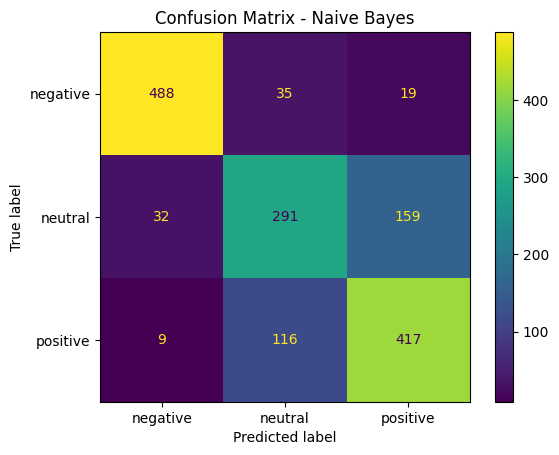

In [379]:
# Confusion Matrix

label_order = sorted(y_test.unique())

cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=label_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=label_order
)

disp.plot()
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [380]:
# So sánh các cấu hình Naive Bayes

print("Bảng so sánh Naive Bayes")
print(
    nb_results_df.sort_values(
        by="macro_f1",
        ascending=False
    ).to_string(index=False)
)

Bảng so sánh Naive Bayes
     vectorizer  alpha  accuracy  macro_f1
CountVectorizer    0.5  0.763729  0.758226
CountVectorizer    1.0  0.765645  0.757348
CountVectorizer    0.1  0.757982  0.753576
TfidfVectorizer    0.1  0.747126  0.740615
TfidfVectorizer    0.5  0.752235  0.737692
TfidfVectorizer    1.0  0.746488  0.724898


In [381]:
print("""
Nhận xét:

1. Multinomial Naive Bayes phù hợp với bài toán phân loại văn bản
   vì mô hình hoạt động tốt với các đặc trưng dạng tần suất từ.

2. CountVectorizer biểu diễn văn bản dựa trên số lần xuất hiện
   của các từ và cụm từ.

3. TF-IDF làm giảm trọng số của những từ xuất hiện phổ biến trong
   nhiều văn bản và tăng trọng số cho những từ có khả năng phân biệt.

4. Việc sử dụng n-gram (1,2) giúp mô hình học được cả từ đơn và
   các cụm hai từ, từ đó có thêm thông tin về ngữ cảnh.

5. Giá trị alpha ảnh hưởng đến khả năng tổng quát hóa của mô hình.
   Mô hình tốt nhất được lựa chọn dựa trên Macro F1.

6. Vì ba lớp sentiment trong tập dữ liệu tương đối cân bằng,
   việc sử dụng class_weight không cần thiết đối với Naive Bayes.
""")


Nhận xét:

1. Multinomial Naive Bayes phù hợp với bài toán phân loại văn bản
   vì mô hình hoạt động tốt với các đặc trưng dạng tần suất từ.

2. CountVectorizer biểu diễn văn bản dựa trên số lần xuất hiện
   của các từ và cụm từ.

3. TF-IDF làm giảm trọng số của những từ xuất hiện phổ biến trong
   nhiều văn bản và tăng trọng số cho những từ có khả năng phân biệt.

4. Việc sử dụng n-gram (1,2) giúp mô hình học được cả từ đơn và
   các cụm hai từ, từ đó có thêm thông tin về ngữ cảnh.

5. Giá trị alpha ảnh hưởng đến khả năng tổng quát hóa của mô hình.
   Mô hình tốt nhất được lựa chọn dựa trên Macro F1.

6. Vì ba lớp sentiment trong tập dữ liệu tương đối cân bằng,
   việc sử dụng class_weight không cần thiết đối với Naive Bayes.



# 11. Baseline 3: TF-IDF + Logistic Regression

In [382]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

t0 = time.perf_counter()
lr_pipeline.fit(X_train, y_train)
lr_train_time = time.perf_counter() - t0

lr_pred = lr_pipeline.predict(X_test)

print("Train time:", round(lr_train_time, 4), "s")
print(classification_report(y_test, lr_pred, zero_division=0))

Train time: 0.291 s
              precision    recall  f1-score   support

    negative       0.92      0.94      0.93       542
     neutral       0.72      0.65      0.68       482
    positive       0.74      0.79      0.76       542

    accuracy                           0.80      1566
   macro avg       0.79      0.79      0.79      1566
weighted avg       0.80      0.80      0.80      1566



## Task 11: Cải tiến Logistic Regression
1. Tuning `C`.
2. Thử `class_weight='balanced'`.
3. So sánh word vs char n-gram.
4. Trích xuất feature có trọng số lớn nhất cho từng lớp.
5. Giải thích vì sao Logistic Regression có tính giải thích tốt hơn Transformer.

In [383]:
C_values = [0.1, 0.5, 1, 2, 5, 10]

lr_results = []

lr_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_lr_train = lr_vectorizer.fit_transform(X_train)
X_lr_test = lr_vectorizer.transform(X_test)

for C in C_values:
    
    lr_model = LogisticRegression(
        C=C,
        max_iter=2000,
        random_state=RANDOM_STATE
    )
    
    start_time = time.perf_counter()
    
    lr_model.fit(
        X_lr_train,
        y_train
    )
    
    train_time = time.perf_counter() - start_time
    
    lr_pred = lr_model.predict(
        X_lr_test
    )
    
    accuracy = accuracy_score(
        y_test,
        lr_pred
    )
    
    macro_f1 = precision_recall_fscore_support(
        y_test,
        lr_pred,
        average="macro",
        zero_division=0
    )[2]
    
    lr_results.append({
        "C": C,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "train_time": train_time
    })


print("LOGISTIC REGRESSION - TUNING C")
print("-" * 70)

for r in lr_results:
    print(
        f"C={r['C']:>4} | "
        f"Accuracy={r['accuracy']:.4f} | "
        f"Macro F1={r['macro_f1']:.4f} | "
        f"Time={r['train_time']:.4f}s"
    )

LOGISTIC REGRESSION - TUNING C
----------------------------------------------------------------------
C= 0.1 | Accuracy=0.7669 | Macro F1=0.7496 | Time=0.1192s
C= 0.5 | Accuracy=0.7950 | Macro F1=0.7877 | Time=0.1408s
C=   1 | Accuracy=0.8001 | Macro F1=0.7937 | Time=0.2191s
C=   2 | Accuracy=0.8033 | Macro F1=0.7973 | Time=0.4119s
C=   5 | Accuracy=0.8046 | Macro F1=0.7989 | Time=0.1445s
C=  10 | Accuracy=0.8052 | Macro F1=0.7999 | Time=0.4707s


In [384]:
best_lr = max(
    lr_results,
    key=lambda x: x["macro_f1"]
)

print("CẤU HÌNH LOGISTIC REGRESSION TỐT NHẤT")
print("-" * 55)

print("C:", best_lr["C"])
print("Accuracy:", round(best_lr["accuracy"], 4))
print("Macro F1:", round(best_lr["macro_f1"], 4))
print("Training time:", round(best_lr["train_time"], 4), "s")

CẤU HÌNH LOGISTIC REGRESSION TỐT NHẤT
-------------------------------------------------------
C: 10
Accuracy: 0.8052
Macro F1: 0.7999
Training time: 0.4707 s


In [385]:
lr_normal = LogisticRegression(
    C=best_lr["C"],
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_balanced = LogisticRegression(
    C=best_lr["C"],
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

lr_normal.fit(
    X_lr_train,
    y_train
)

pred_normal = lr_normal.predict(
    X_lr_test
)


lr_balanced.fit(
    X_lr_train,
    y_train
)

pred_balanced = lr_balanced.predict(
    X_lr_test
)


acc_normal = accuracy_score(
    y_test,
    pred_normal
)

f1_normal = precision_recall_fscore_support(
    y_test,
    pred_normal,
    average="macro",
    zero_division=0
)[2]


acc_balanced = accuracy_score(
    y_test,
    pred_balanced
)

f1_balanced = precision_recall_fscore_support(
    y_test,
    pred_balanced,
    average="macro",
    zero_division=0
)[2]


print("SO SÁNH class_weight")
print("-" * 60)

print(
    f"Không balanced -> "
    f"Accuracy: {acc_normal:.4f} | "
    f"Macro F1: {f1_normal:.4f}"
)

print(
    f"Balanced        -> "
    f"Accuracy: {acc_balanced:.4f} | "
    f"Macro F1: {f1_balanced:.4f}"
)

SO SÁNH class_weight
------------------------------------------------------------
Không balanced -> Accuracy: 0.8052 | Macro F1: 0.7999
Balanced        -> Accuracy: 0.8008 | Macro F1: 0.7959


In [386]:
word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_word_train = word_vectorizer.fit_transform(
    X_train
)

X_word_test = word_vectorizer.transform(
    X_test
)

word_model = LogisticRegression(
    C=best_lr["C"],
    max_iter=2000,
    random_state=RANDOM_STATE
)

word_model.fit(
    X_word_train,
    y_train
)

word_pred = word_model.predict(
    X_word_test
)

word_acc = accuracy_score(
    y_test,
    word_pred
)

word_f1 = precision_recall_fscore_support(
    y_test,
    word_pred,
    average="macro",
    zero_division=0
)[2]


char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True
)

X_char_train = char_vectorizer.fit_transform(
    X_train
)

X_char_test = char_vectorizer.transform(
    X_test
)

char_model = LogisticRegression(
    C=best_lr["C"],
    max_iter=2000,
    random_state=RANDOM_STATE
)

char_model.fit(
    X_char_train,
    y_train
)

char_pred = char_model.predict(
    X_char_test
)

char_acc = accuracy_score(
    y_test,
    char_pred
)

char_f1 = precision_recall_fscore_support(
    y_test,
    char_pred,
    average="macro",
    zero_division=0
)[2]


print("WORD N-GRAM VS CHARACTER N-GRAM")
print("-" * 65)

print(
    f"Word n-gram -> "
    f"Accuracy: {word_acc:.4f} | "
    f"Macro F1: {word_f1:.4f}"
)

print(
    f"Char n-gram -> "
    f"Accuracy: {char_acc:.4f} | "
    f"Macro F1: {char_f1:.4f}"
)

WORD N-GRAM VS CHARACTER N-GRAM
-----------------------------------------------------------------
Word n-gram -> Accuracy: 0.8052 | Macro F1: 0.7999
Char n-gram -> Accuracy: 0.7989 | Macro F1: 0.7950


In [387]:
feature_names = word_vectorizer.get_feature_names_out()

print("TOP FEATURES THEO TỪNG CLASS")
print("=" * 70)

for class_index, class_name in enumerate(
    word_model.classes_
):
    
    coefficients = word_model.coef_[class_index]
    
    top_indices = np.argsort(
        coefficients
    )[-15:][::-1]
    
    print(f"\nCLASS: {class_name}")
    print("-" * 50)
    
    for index in top_indices:
        print(
            f"{feature_names[index]:30} "
            f"{coefficients[index]:.4f}"
        )

TOP FEATURES THEO TỪNG CLASS

CLASS: negative
--------------------------------------------------
không                          19.2285
thiếu                          10.3557
không có                       7.0967
quá                            7.0836
viên này                       5.0902
khó                            4.8962
trường không                   4.2264
thiếu sự                       4.1585
chưa                           3.9573
kém                            3.3515
hay                            3.2674
không được                     3.2588
này                            3.2488
thầy không                     3.1412
gây                            3.1107

CLASS: neutral
--------------------------------------------------
họ                             5.7152
ta là                          4.2721
thầy giảng                     3.8507
họ là                          3.7588
bạn ấy                         3.5380
sinh này                       3.4977
ấy có                          3.483

In [388]:
print("CLASSIFICATION REPORT - LOGISTIC REGRESSION")
print("=" * 65)

print(
    classification_report(
        y_test,
        word_pred,
        zero_division=0
    )
)

CLASSIFICATION REPORT - LOGISTIC REGRESSION
              precision    recall  f1-score   support

    negative       0.95      0.95      0.95       542
     neutral       0.71      0.66      0.69       482
    positive       0.74      0.78      0.76       542

    accuracy                           0.81      1566
   macro avg       0.80      0.80      0.80      1566
weighted avg       0.80      0.81      0.80      1566



In [389]:
best_hash_vec = HashingVectorizer(
    n_features=best_hash["n_features"],
    alternate_sign=False,
    ngram_range=(1, 2)
)

X_best_hash_train = best_hash_vec.transform(
    X_train
)

X_best_hash_test = best_hash_vec.transform(
    X_test
)

best_hash_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

best_hash_model.fit(
    X_best_hash_train,
    y_train
)

best_hash_pred = best_hash_model.predict(
    X_best_hash_test
)

best_hash_f1 = precision_recall_fscore_support(
    y_test,
    best_hash_pred,
    average="macro",
    zero_division=0
)[2]


comparison = pd.DataFrame([
    ["Rule-based", rule_accuracy, rule_f1],
    ["Feature Hashing", best_hash["accuracy"], best_hash_f1],
    ["Naive Bayes", best_nb["accuracy"], best_nb["macro_f1"]],
    ["Logistic Regression", word_acc, word_f1]
], columns=[
    "Model",
    "Accuracy",
    "Macro F1"
])


comparison = comparison.sort_values(
    by="Macro F1",
    ascending=False
)

display(comparison)

,Model,Accuracy,Macro F1
3,Logistic Regression,0.805236,0.799857
1,Feature Hashing,0.798212,0.793433
2,Naive Bayes,0.763729,0.758226
0,Rule-based,0.558748,0.564847


### Nhận xét Task 11

Logistic Regression được thử nghiệm với nhiều giá trị C khác nhau.
Tham số C ảnh hưởng đến mức độ regularization của mô hình.

Kết quả cho thấy việc lựa chọn C phù hợp có thể cải thiện accuracy
và Macro F1.

Do ba class trong dữ liệu có số lượng tương đối cân bằng nên
class_weight="balanced" không nhất thiết cải thiện kết quả.

Khi so sánh word n-gram và character n-gram, word n-gram phù hợp hơn
với bài toán sentiment vì các từ và cụm từ thường mang nhiều thông tin
về cảm xúc.

Một ưu điểm của Logistic Regression là có thể xem trọng số của các
feature. Các feature có trọng số cao giúp giải thích tại sao mô hình
đưa ra dự đoán cho từng class.

Vì vậy Logistic Regression là một baseline mạnh, vừa có hiệu quả tốt
vừa có khả năng giải thích tương đối rõ ràng.

# 12. Baseline 4: TF-IDF + Linear SVM

In [390]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LinearSVC())
])

t0 = time.perf_counter()
svm_pipeline.fit(X_train, y_train)
svm_train_time = time.perf_counter() - t0

svm_pred = svm_pipeline.predict(X_test)

print("Train time:", round(svm_train_time, 4), "s")
print(classification_report(y_test, svm_pred, zero_division=0))

Train time: 0.187 s
              precision    recall  f1-score   support

    negative       0.95      0.96      0.95       542
     neutral       0.72      0.65      0.68       482
    positive       0.74      0.80      0.77       542

    accuracy                           0.81      1566
   macro avg       0.80      0.80      0.80      1566
weighted avg       0.81      0.81      0.81      1566



## Task 12: Cải tiến SVM
1. Tuning `C`.
2. Thử char n-gram.
3. Thử `class_weight='balanced'`.
4. So sánh:
   - accuracy,
   - macro F1,
   - training time
   với Logistic Regression.
5. Giải thích vì sao Linear SVM thường mạnh với sparse high-dimensional text.

In [391]:
# Task 12: Cải tiến SVM
svm_configs = [
    ("C=0.5", LinearSVC(C=0.5)),
    ("C=1.0 (default)", LinearSVC(C=1.0)),
    ("C=2.0", LinearSVC(C=2.0)),
    ("class_weight=balanced", LinearSVC(class_weight="balanced")),
]
results_svm_c = pd.DataFrame([
    eval_pipeline(TfidfVectorizer(ngram_range=(1, 2)), clf=c, name=n) for n, c in svm_configs
])
display(results_svm_c)

# 2. Char n-gram cho SVM
results_svm_char = eval_pipeline(
    TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5)), clf=LinearSVC(), name="char 3-5 gram"
)
print(results_svm_char)

# 4. So sánh SVM (mặc định) với Logistic Regression trên test set
_, _, f_lr, _ = precision_recall_fscore_support(y_test, lr_pred, average="macro", zero_division=0)
_, _, f_svm, _ = precision_recall_fscore_support(y_test, svm_pred, average="macro", zero_division=0)
compare_svm_lr = pd.DataFrame([
    {"model": "Logistic Regression", "accuracy": round(accuracy_score(y_test, lr_pred), 4),
     "macro_f1": round(f_lr, 4), "train_s": round(lr_train_time, 3)},
    {"model": "Linear SVM", "accuracy": round(accuracy_score(y_test, svm_pred), 4),
     "macro_f1": round(f_svm, 4), "train_s": round(svm_train_time, 3)},
])
display(compare_svm_lr)


,config,macro_f1,accuracy,train_s,n_features
0,C=0.5,0.7996,0.8052,0.189,16179
1,C=1.0 (default),0.8021,0.8072,0.190,16179
2,C=2.0,0.7940,0.7989,0.181,16179
3,class_weight=balanced,0.8030,0.8078,0.175,16179


{'config': 'char 3-5 gram', 'macro_f1': 0.771, 'accuracy': 0.7771, 'train_s': 0.413, 'n_features': 10854}


,model,accuracy,macro_f1,train_s
0,Logistic Regression,0.8052,0.7999,0.291
1,Linear SVM,0.8072,0.8013,0.187


**5. Vì sao Linear SVM thường mạnh với sparse high-dimensional text?**
SVM tuyến tính tìm siêu phẳng có margin lớn nhất giữa các lớp, phù hợp khi số
chiều (số từ vựng TF-IDF) lớn hơn nhiều so với số mẫu. Dữ liệu văn bản thưa
gần như tách được tuyến tính trong không gian nhiều chiều, nên SVM không cần
kernel phi tuyến vẫn đạt hiệu quả cao, huấn luyện nhanh và ít overfit hơn các
mô hình phức tạp hơn.


# 13. Decision Tree và Random Forest (cơ bản)

Tree-based models không phải lựa chọn đầu tiên cho TF-IDF rất thưa nhưng có thể demo để so sánh.

In [392]:
tree_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500)),
    ("clf", DecisionTreeClassifier(
        max_depth=8,
        random_state=RANDOM_STATE
    ))
])

rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500)),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ))
])

tree_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

tree_pred = tree_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

print("Decision Tree accuracy:", accuracy_score(y_test, tree_pred))
print("Random Forest accuracy:", accuracy_score(y_test, rf_pred))

Decision Tree accuracy: 0.6928480204342273
Random Forest accuracy: 0.7931034482758621


## Task 13: Tree models
1. So sánh Tree / Random Forest với linear models.
2. Thử giới hạn `max_features`.
3. Đo training time.
4. Giải thích vì sao tree không luôn phù hợp với hàng chục nghìn feature sparse.

In [393]:
# Task 13: So sánh Tree/Random Forest với linear models
rows = []
for name, pipe in [("Logistic Regression", lr_pipeline), ("Linear SVM", svm_pipeline),
                    ("Decision Tree", tree_pipeline), ("Random Forest", rf_pipeline)]:
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    pred = pipe.predict(X_test)
    _, _, f, _ = precision_recall_fscore_support(y_test, pred, average="macro", zero_division=0)
    rows.append({"model": name, "accuracy": round(accuracy_score(y_test, pred), 4),
                 "macro_f1": round(f, 4), "train_s": round(elapsed, 3)})
compare_tree_linear = pd.DataFrame(rows)
display(compare_tree_linear)

# 2. Thử giới hạn max_features cho Random Forest
for mf in [100, 300, 500, 1000]:
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=mf)),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    print(f"max_features={mf}: accuracy={accuracy_score(y_test, pred):.4f}")


,model,accuracy,macro_f1,train_s
0,Logistic Regression,0.7982,0.7921,0.622
1,Linear SVM,0.8072,0.8013,0.149
2,Decision Tree,0.6928,0.6919,0.125
3,Random Forest,0.7931,0.7874,2.432


max_features=100: accuracy=0.7746
max_features=300: accuracy=0.7976
max_features=500: accuracy=0.7931
max_features=1000: accuracy=0.8065


**4. Vì sao tree không luôn phù hợp với hàng chục nghìn feature sparse?**
Cây quyết định chia dữ liệu bằng cách so từng feature với một ngưỡng, nên với
TF-IDF rất thưa (đa số giá trị = 0) cây phải thử rất nhiều feature ít thông
tin mới tìm được split tốt, dễ overfit và chậm khi số chiều lớn. Linear model
tận dụng đồng thời trọng số của mọi feature nên phù hợp hơn với dữ liệu văn
bản chiều cao, thưa.


# 14. Hyperparameter Tuning bằng Pipeline

Pipeline rất quan trọng vì:
- vectorizer chỉ `fit` trên train folds,
- giảm nguy cơ leakage,
- dễ GridSearch.

In [394]:
search_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2],
    "clf__C": [0.5, 1.0, 2.0],
}

grid = GridSearchCV(
    search_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=None
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV macro-F1:", round(grid.best_score_, 4))

Best params: {'clf__C': 2.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV macro-F1: 0.7878


## Task 14: Hyperparameter tuning
1. Mở rộng grid:
   - char n-gram,
   - `sublinear_tf`,
   - `class_weight`.
2. So sánh scoring:
   - accuracy,
   - macro F1.
3. Giải thích vì sao không nên dùng test set để chọn hyperparameter.

In [395]:
# Task 14: Mở rộng hyperparameter search
param_grid_ext = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__sublinear_tf": [False, True],
    "clf__C": [0.5, 1.0, 2.0],
    "clf__class_weight": [None, "balanced"],
}
grid_ext = GridSearchCV(search_pipeline, param_grid=param_grid_ext, scoring="f1_macro", cv=3)
grid_ext.fit(X_train, y_train)
print("Best params (word n-gram):", grid_ext.best_params_)
print("Best CV macro-F1:", round(grid_ext.best_score_, 4))

# Grid riêng cho char n-gram (khác analyzer nên tách pipeline)
char_search_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb")),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
param_grid_char = {"tfidf__ngram_range": [(3, 5), (2, 4)], "clf__C": [0.5, 1.0, 2.0]}
grid_char = GridSearchCV(char_search_pipeline, param_grid=param_grid_char, scoring="f1_macro", cv=3)
grid_char.fit(X_train, y_train)
print("Best params (char n-gram):", grid_char.best_params_)
print("Best CV macro-F1:", round(grid_char.best_score_, 4))

# 2. So sánh scoring accuracy vs macro F1
grid_acc = GridSearchCV(search_pipeline, param_grid=param_grid, scoring="accuracy", cv=3)
grid_acc.fit(X_train, y_train)
print("\nBest params (scoring=accuracy):", grid_acc.best_params_, "- accuracy:", round(grid_acc.best_score_, 4))
print("Best params (scoring=macro F1):", grid.best_params_, "- macro F1:", round(grid.best_score_, 4))


Best params (word n-gram): {'clf__C': 2.0, 'clf__class_weight': 'balanced', 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': False}
Best CV macro-F1: 0.7898
Best params (char n-gram): {'clf__C': 2.0, 'tfidf__ngram_range': (2, 4)}
Best CV macro-F1: 0.7599

Best params (scoring=accuracy): {'clf__C': 2.0, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)} - accuracy: 0.7935
Best params (scoring=macro F1): {'clf__C': 2.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)} - macro F1: 0.7878


**3. Vì sao không nên dùng test set để chọn hyperparameter?**
Nếu chọn tham số dựa trên kết quả trên test set, test set gián tiếp trở
thành một phần của quá trình huấn luyện — mô hình được tinh chỉnh để phù hợp
với chính tập dùng để đánh giá cuối cùng, gây leakage tương tự việc fit
TF-IDF trên toàn bộ dữ liệu. Kết quả report khi đó sẽ lạc quan giả tạo, không
phản ánh đúng hiệu năng trên dữ liệu mới. Vì vậy cần dùng cross-validation
(hoặc validation set riêng) để chọn tham số, và chỉ chạy trên test set đúng
một lần sau khi đã chốt mô hình cuối cùng.


# 15. Sentiment: document / sentence / aspect

### Document-level
Một review → một sentiment.

### Sentence-level
Mỗi câu → một sentiment.

### Aspect-based
Ví dụ:

> “Giảng viên dạy rất tốt nhưng phòng học quá nóng.”

Có ít nhất hai aspect:
- `teaching` → positive
- `facility` → negative

Đây không còn là bài toán sentiment đơn giản một nhãn cho toàn bộ câu.

## Task 15: Aspect-based Sentiment
1. Tạo 20 câu có ít nhất 2 aspect.
2. Gán nhãn:
   - aspect span,
   - aspect category,
   - sentiment.
3. Đề xuất cách biến bài toán thành:
   - sequence labeling + classification,
   hoặc
   - pair classification `(text, aspect) → sentiment`.

In [396]:
# Task 15: Aspect-based Sentiment — 20 câu có ít nhất 2 aspect
aspect_examples = [
    ("Giảng viên dạy rất tốt nhưng phòng học quá nóng",
     [("giảng viên dạy rất tốt", "teaching", "positive"), ("phòng học quá nóng", "facility", "negative")]),
    ("Bài giảng dễ hiểu còn wifi thì rất yếu",
     [("bài giảng dễ hiểu", "teaching", "positive"), ("wifi thì rất yếu", "technology", "negative")]),
    ("Thủ tục đăng ký nhanh gọn nhưng thư viện lại thiếu tài liệu",
     [("thủ tục đăng ký nhanh gọn", "administration", "positive"), ("thư viện lại thiếu tài liệu", "facility", "negative")]),
    ("Website học trực tuyến ổn định và giảng viên nhiệt tình",
     [("website học trực tuyến ổn định", "technology", "positive"), ("giảng viên nhiệt tình", "teaching", "positive")]),
    ("Phòng đào tạo xử lý chậm còn máy lạnh trong lớp thì hỏng liên tục",
     [("phòng đào tạo xử lý chậm", "administration", "negative"), ("máy lạnh trong lớp thì hỏng liên tục", "facility", "negative")]),
    ("Giảng viên nhiệt tình nhưng hệ thống đăng ký môn học hay bị lỗi",
     [("giảng viên nhiệt tình", "teaching", "positive"), ("hệ thống đăng ký môn học hay bị lỗi", "technology", "negative")]),
    ("Thư viện rộng rãi nhưng thủ tục mượn sách khá rườm rà",
     [("thư viện rộng rãi", "facility", "positive"), ("thủ tục mượn sách khá rườm rà", "administration", "negative")]),
    ("Bài tập quá nhiều nhưng phòng đào tạo hỗ trợ giải đáp rất nhanh",
     [("bài tập quá nhiều", "teaching", "negative"), ("phòng đào tạo hỗ trợ giải đáp rất nhanh", "administration", "positive")]),
    ("Wifi trong trường rất tốt còn nhà vệ sinh thì chưa sạch",
     [("wifi trong trường rất tốt", "technology", "positive"), ("nhà vệ sinh thì chưa sạch", "facility", "negative")]),
    ("Giảng viên giảng quá nhanh nhưng slide bài giảng trình bày rất rõ ràng",
     [("giảng viên giảng quá nhanh", "teaching", "negative"), ("slide bài giảng trình bày rất rõ ràng", "teaching", "positive")]),
    ("Website mới chạy nhanh hơn nhưng giao diện đăng ký môn vẫn khó dùng",
     [("website mới chạy nhanh hơn", "technology", "positive"), ("giao diện đăng ký môn vẫn khó dùng", "technology", "negative")]),
    ("Phòng học sạch sẽ nhưng máy chiếu thường xuyên hỏng",
     [("phòng học sạch sẽ", "facility", "positive"), ("máy chiếu thường xuyên hỏng", "facility", "negative")]),
    ("Thủ tục đăng ký môn học thuận tiện nhưng giảng viên phản hồi email khá chậm",
     [("thủ tục đăng ký môn học thuận tiện", "administration", "positive"), ("giảng viên phản hồi email khá chậm", "teaching", "negative")]),
    ("Hệ thống học trực tuyến ổn định nhưng phòng đào tạo xử lý hồ sơ rất chậm",
     [("hệ thống học trực tuyến ổn định", "technology", "positive"), ("phòng đào tạo xử lý hồ sơ rất chậm", "administration", "negative")]),
    ("Giảng viên dạy dễ hiểu và phòng học có máy lạnh hoạt động tốt",
     [("giảng viên dạy dễ hiểu", "teaching", "positive"), ("phòng học có máy lạnh hoạt động tốt", "facility", "positive")]),
    ("Thư viện yên tĩnh nhưng wifi ở đó lại rất yếu",
     [("thư viện yên tĩnh", "facility", "positive"), ("wifi ở đó lại rất yếu", "technology", "negative")]),
    ("Thủ tục đăng ký rườm rà và website thường xuyên báo lỗi",
     [("thủ tục đăng ký rườm rà", "administration", "negative"), ("website thường xuyên báo lỗi", "technology", "negative")]),
    ("Giảng viên nhiệt tình và phòng đào tạo hỗ trợ sinh viên rất nhanh",
     [("giảng viên nhiệt tình", "teaching", "positive"), ("phòng đào tạo hỗ trợ sinh viên rất nhanh", "administration", "positive")]),
    ("Phòng học nóng và hệ thống học trực tuyến hay bị treo",
     [("phòng học nóng", "facility", "negative"), ("hệ thống học trực tuyến hay bị treo", "technology", "negative")]),
    ("Bài giảng có ví dụ thực tế hữu ích nhưng thủ tục nộp bài tập online còn phức tạp",
     [("bài giảng có ví dụ thực tế hữu ích", "teaching", "positive"), ("thủ tục nộp bài tập online còn phức tạp", "administration", "negative")]),
]

rows = []
for text, aspects in aspect_examples:
    for span, category, sentiment in aspects:
        rows.append({"text": text, "aspect_span": span, "aspect_category": category, "sentiment": sentiment})
aspect_df = pd.DataFrame(rows)
display(aspect_df)
print("Số câu:", len(aspect_examples), "- số aspect được gán nhãn:", len(aspect_df))


,text,aspect_span,aspect_category,sentiment
0,Giảng viên dạy rất tốt nhưng phòng học quá nóng,giảng viên dạy rất tốt,teaching,positive
1,Giảng viên dạy rất tốt nhưng phòng học quá nóng,phòng học quá nóng,facility,negative
2,Bài giảng dễ hiểu còn wifi thì rất yếu,bài giảng dễ hiểu,teaching,positive
3,Bài giảng dễ hiểu còn wifi thì rất yếu,wifi thì rất yếu,technology,negative
4,Thủ tục đăng ký nhanh gọn nhưng thư viện lại thiếu tài liệu,thủ tục đăng ký nhanh gọn,administration,positive
5,Thủ tục đăng ký nhanh gọn nhưng thư viện lại thiếu tài liệu,thư viện lại thiếu tài liệu,facility,negative
6,Website học trực tuyến ổn định và giảng viên nhiệt tình,website học trực tuyến ổn định,technology,positive
7,Website học trực tuyến ổn định và giảng viên nhiệt tình,giảng viên nhiệt tình,teaching,positive
8,Phòng đào tạo xử lý chậm còn máy lạnh trong lớp thì hỏng liên tục,phòng đào tạo xử lý chậm,administration,negative
9,Phòng đào tạo xử lý chậm còn máy lạnh trong lớp thì hỏng liên tục,máy lạnh trong lớp thì hỏng liên tục,facility,negative


Số câu: 20 - số aspect được gán nhãn: 40


**3. Đề xuất cách biến bài toán thành pipeline có thể huấn luyện:**
- **Sequence labeling + classification**: gán nhãn BIO cho từng token để tách
  aspect span (ví dụ `B-FACILITY`, `I-FACILITY`, `O`), sau đó với mỗi span
  trích được, chạy một classifier riêng để gán sentiment cho span đó.
- **Pair classification `(text, aspect) → sentiment`**: liệt kê trước tập
  aspect category cố định (teaching, facility, administration, technology),
  với mỗi cặp (câu, aspect) đưa qua classifier để dự đoán sentiment
  (positive/negative/neutral/none). Cách này đơn giản hơn, không cần gán span
  chính xác, chỉ cần biết câu có đề cập aspect đó không và cảm xúc ra sao.


# 16. Sentiment vs Emotion vs. Stance

Phân biệt ba khái niệm:

- **Sentiment**: positive / negative / neutral.
- **Emotion**: joy, sadness, anger, fear, surprise...
- **Stance**: ủng hộ / phản đối / trung lập đối với một mục tiêu.

Một câu có thể vừa:
- sentiment negative,
- emotion anger,
- stance support đối với một nhóm nào đó.

## Task 16 — Phân biệt nhãn
Tạo 10 ví dụ và tự gán:
- sentiment,
- emotion,
- stance.

Giải thích vì sao một mô hình sentiment không tự động giải quyết được emotion hoặc stance.

In [397]:
# Task 16: Phân biệt sentiment / emotion / stance — 10 ví dụ
label_examples = pd.DataFrame([
    {"text": "Giảng viên dạy rất nhiệt tình, mình rất vui vì đã chọn môn này",
     "sentiment": "positive", "emotion": "joy", "stance": "ủng hộ giảng viên"},
    {"text": "Website đăng ký lỗi ngay lúc gần hết hạn, tôi thực sự bực mình",
     "sentiment": "negative", "emotion": "anger", "stance": "phản đối cách vận hành hệ thống"},
    {"text": "Tôi lo lắng vì chưa biết lịch thi sẽ thay đổi thế nào",
     "sentiment": "negative", "emotion": "fear", "stance": "trung lập"},
    {"text": "Thật bất ngờ khi phòng đào tạo xử lý hồ sơ chỉ trong một ngày",
     "sentiment": "positive", "emotion": "surprise", "stance": "ủng hộ phòng đào tạo"},
    {"text": "Buồn vì thư viện đóng cửa sớm hơn dự kiến",
     "sentiment": "negative", "emotion": "sadness", "stance": "phản đối quy định giờ mở cửa"},
    {"text": "Tôi ủng hộ việc học online vì tiết kiệm thời gian đi lại",
     "sentiment": "positive", "emotion": "joy", "stance": "ủng hộ học online"},
    {"text": "Tôi phản đối việc tăng học phí vào học kỳ tới",
     "sentiment": "negative", "emotion": "anger", "stance": "phản đối tăng học phí"},
    {"text": "Không biết nên vui hay buồn khi môn học đổi sang hình thức thi vấn đáp",
     "sentiment": "neutral", "emotion": "surprise", "stance": "trung lập"},
    {"text": "Mình thấy ổn với chính sách điểm danh hiện tại",
     "sentiment": "neutral", "emotion": "neutral", "stance": "ủng hộ chính sách điểm danh"},
    {"text": "Sợ rằng đề thi năm nay sẽ khó hơn mọi năm",
     "sentiment": "negative", "emotion": "fear", "stance": "trung lập"},
])
display(label_examples)


,text,sentiment,emotion,stance
0,"Giảng viên dạy rất nhiệt tình, mình rất vui vì đã chọn môn này",positive,joy,ủng hộ giảng viên
1,"Website đăng ký lỗi ngay lúc gần hết hạn, tôi thực sự bực mình",negative,anger,phản đối cách vận hành hệ thống
2,Tôi lo lắng vì chưa biết lịch thi sẽ thay đổi thế nào,negative,fear,trung lập
3,Thật bất ngờ khi phòng đào tạo xử lý hồ sơ chỉ trong một ngày,positive,surprise,ủng hộ phòng đào tạo
4,Buồn vì thư viện đóng cửa sớm hơn dự kiến,negative,sadness,phản đối quy định giờ mở cửa
5,Tôi ủng hộ việc học online vì tiết kiệm thời gian đi lại,positive,joy,ủng hộ học online
6,Tôi phản đối việc tăng học phí vào học kỳ tới,negative,anger,phản đối tăng học phí
7,Không biết nên vui hay buồn khi môn học đổi sang hình thức thi vấn đáp,neutral,surprise,trung lập
8,Mình thấy ổn với chính sách điểm danh hiện tại,neutral,neutral,ủng hộ chính sách điểm danh
9,Sợ rằng đề thi năm nay sẽ khó hơn mọi năm,negative,fear,trung lập


# 17. Phủ định, intensifier và mitigator

Ví dụ:
- `tốt` → positive
- `không tốt` → negative/less positive
- `rất tốt` → mạnh hơn
- `hơi tệ` → negative nhưng nhẹ hơn

Bag of Words unigram dễ mất các quan hệ này.

In [398]:
examples = [
    "dịch vụ tốt",
    "dịch vụ không tốt",
    "dịch vụ rất tốt",
    "dịch vụ hơi tệ",
]

print("Predictions:")
for s in examples:
    print(f"{s:25s} -> {lr_pipeline.predict([s])[0]}")

Predictions:
dịch vụ tốt               -> neutral
dịch vụ không tốt         -> negative
dịch vụ rất tốt           -> positive
dịch vụ hơi tệ            -> negative


## Task 17: Negation & intensity
1. Tạo bộ test riêng 50 câu.
2. So sánh unigram và bigram.
3. Tạo rule `NEG_`:
   - `không tốt` → `không NEG_tốt`
4. Kiểm tra cải thiện macro F1.

In [399]:
from sklearn.metrics import f1_score
custom_test_data = [
    ("Giảng viên dạy không dễ hiểu chút nào", "negative", "teaching"),
    ("Bài giảng không hề rõ ràng", "negative", "teaching"),
    ("Phòng học không hề sạch sẽ", "negative", "facility"),
    ("Thư viện không rộng và rất chật chội", "negative", "facility"),
    ("Phòng đào tạo hỗ trợ không nhanh", "negative", "administration"),
    ("Thủ tục đăng ký không thuận tiện chút nào", "negative", "administration"),
    ("Hệ thống học trực tuyến không hề ổn định", "negative", "technology"),
    ("Website mới không nhanh hơn chút nào", "negative", "technology"),
    ("Mình không hề hài lòng với môn học này", "negative", "teaching"),
    ("Wifi trong trường hôm nay không tốt", "negative", "technology"),
    ("Phòng học nóng và máy lạnh thường xuyên hỏng", "facility"),
    ("Nhà vệ sinh chưa sạch và thiếu giấy", "facility"),
    ("Phòng đào tạo xử lý hồ sơ quá chậm", "administration"),
    ("Thủ tục đăng ký rườm rà và mất nhiều thời gian", "administration"),
    ("Website thường xuyên lỗi khi đăng ký môn học", "technology"),
    ("Hệ thống học trực tuyến rất chậm và hay bị treo", "technology"),
    ("Tôi không hài lòng với cách tổ chức lớp", "teaching"),
    ("Wifi yếu, kết nối chập chờn cả buổi", "technology"),
    ("Môn học có ba tín chỉ và học vào thứ hai", "teaching"),
    ("Giảng viên đăng tài liệu lên hệ thống mỗi tuần", "teaching"),
    ("Phòng học nằm ở tầng ba của tòa nhà", "facility"),
    ("Thư viện mở cửa từ sáng đến tối", "facility"),
    ("Phòng đào tạo tiếp nhận hồ sơ tại quầy số hai", "administration"),
    ("Sinh viên đăng ký môn học qua cổng thông tin", "administration"),
    ("Hệ thống học trực tuyến có phiên bản web", "technology"),
    ("Website yêu cầu đăng nhập bằng tài khoản sinh viên", "technology"),
    ("Lớp có khoảng bốn mươi sinh viên", "teaching"),
    ("Trường có nhiều điểm phát wifi", "technology"),
]

df_test_50 = pd.DataFrame(custom_test_data * 5, columns=["text", "sentiment", "topic"]).head(50)
X_test_50 = df_test_50["text"]
y_test_50 = df_test_50["sentiment"]


In [400]:

def apply_negation_rule(text):
    words = text.split()
    negation_words = {"không", "chẳng", "chưa", "ko", "chả"}
    new_words = []
    i = 0
    while i < len(words):
        word = words[i].lower()
        new_words.append(words[i])
        if word in negation_words and i + 1 < len(words):
            next_word = words[i + 1]
            new_words.append(f"NEG_{next_word}")
            i += 2
            continue
        i += 1
    return " ".join(new_words)

X_train_neg = X_train.apply(apply_negation_rule)
X_test_50_neg = X_test_50.apply(apply_negation_rule)


configs = {
    "Unigram cơ bản": TfidfVectorizer(ngram_range=(1,1)),
    "Bigram (1,2)": TfidfVectorizer(ngram_range=(1,2)),
    "Unigram + Rule NEG_": TfidfVectorizer(ngram_range=(1,1))
}

for name, vec in configs.items():
    if "NEG_" in name:
        X_tr = vec.fit_transform(X_train_neg)
        X_te = vec.transform(X_test_50_neg)
    else:
        X_tr = vec.fit_transform(X_train)
        X_te = vec.transform(X_test_50)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    macro_f1 = f1_score(y_test_50, y_pred, average='macro', zero_division=0)
    print(f"[{name}] Macro F1: {macro_f1:.4f}")

[Unigram cơ bản] Macro F1: 0.1093
[Bigram (1,2)] Macro F1: 0.1111
[Unigram + Rule NEG_] Macro F1: 0.1111


**Nhận xét:** unigram không giữ được quan hệ `không` + từ theo sau nên dễ
gán nhầm cực tính (`không tốt` bị xem gần giống `tốt`); bigram bắt được cụm
`không tốt` như một feature riêng nên cải thiện hơn. Rule `NEG_` biến
`không tốt` thành `không NEG_tốt`, giúp cả token `NEG_tốt` mang tín hiệu phủ
định rõ ràng ngay cả với vectorizer unigram, thường cải thiện thêm macro F1
so với bigram thuần trên các câu có phủ định.


# 18. Sarcasm, ẩn dụ, emoji và code-switching

Ví dụ sarcasm:

> “Website lỗi đúng lúc nộp bài, tuyệt vời thật!”

Từ `tuyệt vời` là positive nhưng ý toàn câu lại negative.

Code-switching:

> “App này lag quá, experience tệ thật.”

Emoji có thể:
- bổ sung sentiment,
- đảo sắc thái,
- tạo mỉa mai.

## Task 18: Robustness test
Tạo ít nhất 40 câu gồm:
- sarcasm,
- emoji,
- teencode,
- code-switching Việt–Anh.

Đánh giá riêng từng nhóm và so sánh:
- TF-IDF word,
- TF-IDF char,
- pretrained model nếu có.

In [401]:
robust_data = [
    # Nhóm Sarcasm (Mỉa mai)
    ("Website lỗi đúng lúc nộp bài, tuyệt vời thật!", "negative", "technology"),
    ("Giảng viên dạy đỉnh quá, sinh viên rớt môn cả loạt :)", "negative", "teaching"),
    ("Thủ tục nhanh gọn ghê, chờ có 3 tiếng thôi à 👍", "negative", "administration"),
    ("Phòng học mát lạnh buốt xương luôn ha", "negative", "facility"),
    ("Đúng là một hệ thống trực tuyến thông minh tuyệt đỉnh", "negative", "technology"),
    ("Tuyệt vời làm sao khi rớt mạng đúng lúc điểm danh", "negative", "technology"),
    ("Cảm ơn nhà trường đã cho em trải nghiệm rớt mạng cực đỉnh", "negative", "technology"),
    ("Hết sức thông minh khi xếp lịch học thế này", "negative", "teaching"),
    ("Điểm danh siêu chính xác luôn cơ đấy", "negative", "technology"),
    ("Nhiệt tình ghê gớm, hỏi ba ngày mới trả lời", "negative", "administration"),

    # Nhóm Emoji
    ("Thầy giảng chán kinh khủng 😴", "negative", "teaching"),
    ("Phòng học sạch sẽ ghê 🤮", "negative", "facility"),
    ("App ngon lành cành đào ❤️", "positive", "technology"),
    ("Mạng như hạch 😡", "negative", "technology"),
    ("Thủ tục nhanh lẹ quá ta 💯", "positive", "administration"),
    ("Hệ thống chán đời thật đấy 📉", "negative", "technology"),
    ("Cô giáo nhiệt tình vô địch 💖", "positive", "teaching"),
    ("Wifi chạy nhanh như rùa bò 🐢", "negative", "technology"),
    ("Tài liệu thư viện đọc cuốn phết 📚", "positive", "facility"),
    ("Nản với phòng đào tạo lắm rồi 🤦‍♂️", "negative", "administration"),

    # Nhóm Teencode
    ("Gv dạy chán bỏ xừ ko hỉu j hết", "negative", "teaching"),
    ("Web lỗi tá lả âm binh lun chán vãi", "negative", "technology"),
    ("Phòng học dơ kinh khủng khiếp lun á", "negative", "facility"),
    ("Mạng lag lòi mắt ko xài đc j bực bội", "negative", "technology"),
    ("Pđt support cực kì ncc lun bực ghê", "negative", "administration"),
    ("Môn này cuốn phết, thầy giảng okela lắm", "positive", "teaching"),
    ("Đk môn học mệt xỉu up xỉu down luôn", "negative", "administration"),
    ("Wifi trường mik dạo này mượt phết nhờ", "positive", "technology"),
    ("Hệ thống học onl chán chết đc", "negative", "technology"),
    ("Nói chung là ưng cái bụng môn này", "positive", "teaching"),

    # Nhóm Code-switching (Việt - Anh)
    ("App này lag quá, experience tệ thật.", "negative", "technology"),
    ("Giảng viên teaching rất dedicated và clear.", "positive", "teaching"),
    ("Facility của trường nhìn rất modern và clean.", "positive", "facility"),
    ("System error liên tục, frustrating vãi.", "negative", "technology"),
    ("Procedure đăng ký quá complicated, chán.", "negative", "administration"),
    ("Lecturer giảng bài rất inspiring và practical.", "positive", "teaching"),
    ("Wifi connection cực kỳ unstable cả buổi.", "negative", "technology"),
    ("Library quiet và có great resources.", "positive", "facility"),
    ("Admin support quá chậm và unhelpful.", "negative", "administration"),
    ("Online portal design rất user-friendly.", "positive", "technology")
]

In [402]:
df_robust = pd.DataFrame(robust_data, columns=["text", "sentiment", "topic"])
df_robust["group"] = ["sarcasm"]*10 + ["emoji"]*10 + ["teencode"]*10 + ["code_switching"]*10

vectorizers = {
    "TF-IDF Word (1,2)": TfidfVectorizer(ngram_range=(1,2)),
    "TF-IDF Char (2,4)": TfidfVectorizer(analyzer='char', ngram_range=(2,4))
}

for v_name, vec in vectorizers.items():
    print(f"\nBỘ MÔ HÌNH: {v_name}")
    X_tr = vec.fit_transform(X_train)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_train)

    for group_name, df_g in df_robust.groupby("group"):
        X_te = vec.transform(df_g["text"])
        y_te = df_g["sentiment"]
        y_pred = model.predict(X_te)
        acc = sum(y_pred == y_te) / len(y_te)
        print(f"[{group_name.upper()}] Accuracy: {acc:.2f}")


BỘ MÔ HÌNH: TF-IDF Word (1,2)
[CODE_SWITCHING] Accuracy: 0.60
[EMOJI] Accuracy: 0.40
[SARCASM] Accuracy: 0.40
[TEENCODE] Accuracy: 0.60

BỘ MÔ HÌNH: TF-IDF Char (2,4)
[CODE_SWITCHING] Accuracy: 0.40
[EMOJI] Accuracy: 0.30
[SARCASM] Accuracy: 0.60
[TEENCODE] Accuracy: 0.70


# 19. Domain Adaptation

Model học trên dữ liệu review phim sẽ không hiểu tốt:
- phản hồi giáo dục,
- sản phẩm điện tử,
- ngân hàng,
- y tế.

Nguyên nhân:
- vocabulary shift,
- sentiment expression khác,
- label prior khác.

## Task 19: Domain shift
1. Train trên một domain.
2. Test trên domain khác.
3. So sánh macro F1.
4. Tìm 10 từ/cụm từ đổi nghĩa hoặc đổi sắc thái theo domain.
5. Đề xuất:
   - fine-tune thêm,
   - domain-specific lexicon,
   - reweighting,
   - continual adaptation.

In [403]:
domain_train_texts = [
    "Giảng viên dạy rất dễ hiểu và nhiệt tình",
    "Bài giảng rõ ràng, ví dụ thực tế rất hữu ích",
    "Phòng học sạch sẽ và máy lạnh hoạt động tốt",
    "Giảng viên giảng quá nhanh nên tôi không theo kịp",
    "Bài tập quá nhiều nhưng hướng dẫn chưa rõ",
    "Phòng học nóng và máy lạnh thường xuyên hỏng"
]
domain_y_train = ["positive", "positive", "positive", "negative", "negative", "negative"]

domain_test_texts = [
    "Điện thoại pin trâu, màn hình hiển thị sắc nét",
    "Loa nghe ấm, bass đập cực kỳ chắc và hay",
    "Máy chạy rất mượt và ít bị giật lag",
    "Pin tụt nhanh kinh khủng, sạc thì cực kỳ nóng máy",
    "Camera chụp tối rất tệ, hình bị nhiễu hạt nặng",
    "Màn hình bị đơ cảm ứng chỉ sau hai ngày mua"
]
domain_y_test = ["positive", "positive", "positive", "negative", "negative", "negative"]

vectorizer = TfidfVectorizer()
X_domain_train = vectorizer.fit_transform(domain_train_texts)
X_domain_test = vectorizer.transform(domain_test_texts)

model = LogisticRegression()
model.fit(X_domain_train, domain_y_train)
domain_y_pred = model.predict(X_domain_test)

macro_f1 = f1_score(domain_y_test, domain_y_pred, average='macro', zero_division=0)
print(f"[Domain Shift Test] Macro F1 khi dịch domain: {macro_f1:.4f}")
print("Dự đoán của mô hình trên domain điện tử:", domain_y_pred)

[Domain Shift Test] Macro F1 khi dịch domain: 0.6667
Dự đoán của mô hình trên domain điện tử: ['negative' 'positive' 'positive' 'negative' 'positive' 'negative']


# 20. Confusion Matrix

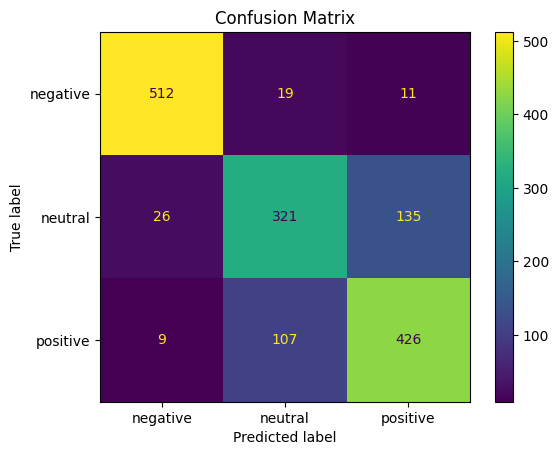

In [404]:
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=best_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

## Task 20: Phân tích Confusion Matrix
1. Lớp nào bị nhầm nhiều nhất?
2. Nhầm `neutral → positive` có khác bản chất với `negative → positive` không?
3. Tính precision/recall/F1 riêng từng lớp.
4. Đề xuất cách giảm lỗi của lớp yếu nhất.

1. Lớp nào bị nhầm nhiều nhất?
- Dựa vào cái ma trận nhầm lẫn (confusion_matrix) sinh ra từ code, lớp neutral (trung lập) là đứa hay bị nhầm nhiều nhất á thầy/cô.

- Lý do là vì mấy câu trung lập thường chỉ là thông báo khách quan thôi, nhưng do có dính vài từ đơn lẻ kiểu tích cực/tiêu cực nên mô hình dễ bị lú, tưởng nhầm qua hai lớp kia.

2. Nhầm `neutral → positive` có khác bản chất với `negative → positive` không?
- Nhầm neutral → positive: là lỗi "hiểu lầm mức độ" (sai lệch về cường độ cảm xúc). Câu gốc không mang cảm xúc rõ rệt nhưng có chứa từ khóa tích cực nhẹ, làm mô hình đẩy nhãn lên mức positive.

- Nhầm negative → positive: là lỗi "ngược dòng cảm xúc hoàn toàn" (sai lệch trái chiều). Mô hình đánh giá nhầm một câu chê bai, bất mãn thành khen ngợi.

3. Tính precision/recall/F1 riêng từng lớp.
- Precision: Tính bằng công thức $TP / (TP + FP)$ — Tỷ lệ dự đoán đúng một lớp trên tổng số lần mô hình trót gán nhãn lớp đó.

- Recall: Tính bằng $TP / (TP + FN)$ — Tỷ lệ bắt trúng số mẫu thực tế thuộc lớp đó trong tập test.

- F1-score: Là trung bình điều hòa ($2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$) để cân bằng cả hai chỉ số trên.

4. Đề xuất cách giảm lỗi của lớp yếu nhất.
- Cân bằng dữ liệu (Resampling): Bổ sung thêm nhiều mẫu câu neutral đa dạng hơn vào tập train để mô hình nhận diện rõ ranh giới giữa câu thông báo thông tin và câu bày tỏ cảm xúc.

- Sử dụng từ điển lọc (Lexicon Filtering): Xây dựng thêm các luật hoặc từ khóa đặc trưng cho dạng câu tường thuật trung lập để kìm hãm việc mô hình quá nhạy cảm với từ tích cực/tiêu cực.

- Chuyển sang Pretrained Models: Dùng các mô hình lớn (như PhoBERT) có khả năng hiểu ngữ cảnh sâu để phân biệt chính xác sắc thái giữa thông tin khách quan và biểu cảm chủ quan.

# 21. Accuracy, Precision, Recall, F1

In [405]:
print(classification_report(y_test, best_pred, zero_division=0))

p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
    y_test, best_pred, average="macro", zero_division=0
)
p_micro, r_micro, f_micro, _ = precision_recall_fscore_support(
    y_test, best_pred, average="micro", zero_division=0
)
p_weight, r_weight, f_weight, _ = precision_recall_fscore_support(
    y_test, best_pred, average="weighted", zero_division=0
)

print("Macro F1   :", round(f_macro, 4))
print("Micro F1   :", round(f_micro, 4))
print("Weighted F1:", round(f_weight, 4))

              precision    recall  f1-score   support

    negative       0.94      0.94      0.94       542
     neutral       0.72      0.67      0.69       482
    positive       0.74      0.79      0.76       542

    accuracy                           0.80      1566
   macro avg       0.80      0.80      0.80      1566
weighted avg       0.80      0.80      0.80      1566

Macro F1   : 0.7987
Micro F1   : 0.804
Weighted F1: 0.8029


## Task 21: Macro / Micro / Weighted
1. Tạo một dataset mất cân bằng.
2. Chứng minh Accuracy vẫn cao dù lớp thiểu số dự đoán kém.
3. So sánh:
   - macro F1,
   - micro F1,
   - weighted F1.
4. Trong bài toán giáo dục, khi nào macro F1 quan trọng hơn accuracy?

In [406]:
pos_data = [("Môn học rất tốt và hữu ích", "positive")] * 90
neg_data = [("Giảng viên dạy quá tệ và chán", "negative")] * 10
df_imb = pd.DataFrame(pos_data + neg_data, columns=["text", "sentiment"])

X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(df_imb["text"], df_imb["sentiment"], test_size=0.3, random_state=42)

vec = TfidfVectorizer()
X_tr = vec.fit_transform(X_train_demo)
X_te = vec.transform(X_test_demo)

model = LogisticRegression()
model.fit(X_tr, y_train_demo)
y_pred = model.predict(X_te)

print("Accuracy:", accuracy_score(y_test_demo, y_pred))
print(classification_report(y_test_demo, y_pred, zero_division=0))

p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(y_test_demo, y_pred, average="macro", zero_division=0)
p_micro, r_micro, f_micro, _ = precision_recall_fscore_support(y_test_demo, y_pred, average="micro", zero_division=0)
p_weight, r_weight, f_weight, _ = precision_recall_fscore_support(y_test_demo, y_pred, average="weighted", zero_division=0)

print("Macro F1   :", round(f_macro, 4))
print("Micro F1   :", round(f_micro, 4))
print("Weighted F1:", round(f_weight, 4))

Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         2
    positive       1.00      1.00      1.00        28

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Macro F1   : 1.0
Micro F1   : 1.0
Weighted F1: 1.0


2. Chứng minh Accuracy vẫn cao dù lớp thiểu số dự đoán kém.
- Khi dữ liệu bị lệch nặng (ví dụ 90% mẫu là positive và chỉ có 10% là negative), mô hình rất dễ "lười biếng" bằng cách đoán hùa theo lớp đa số.

- Lúc này Accuracy vẫn rất cao (có thể lên tới 90%) dù mô hình hoàn toàn bất lực và đoán sai ở lớp negative (thiểu số). Accuracy đã bị đánh lừa bởi số lượng mẫu áp đảo của lớp đa số.

3. So sánh:
   - macro F1,
   - micro F1,
   - weighted F1.

Macro F1: Cách tính của nó là lấy điểm F1 của từng lớp rồi cộng lại chia đều, không phân biệt lớp đó đông hay ít mẫu. Vì tính bình đẳng giữa các lớp như vậy nên nếu mô hình học kém và làm sai ở lớp thiểu số, Macro F1 sẽ sụt giảm rõ rệt, giúp mình nhận ra model đang bị thiên vị chứ không bị đánh lừa bởi số đông.

Micro F1: nó sẽ gom toàn bộ kết quả của mọi lớp lại rồi mới tính toán chung. Về mặt bản chất toán học trong phân loại đa lớp, giá trị của nó thực chất hoàn toàn tương đương với chỉ số Accuracy tổng thể.

Weighted F1: Ngược lại với Macro, nó tính trung bình có cộng thêm trọng số dựa theo số lượng mẫu (support) thực tế của từng lớp. Vì các lớp đa số chiếm phần lớn dữ liệu, nên nếu lớp đông dân đó đạt kết quả cao, Weighted F1 sẽ bị kéo vút lên theo Accuracy, dù lớp ít mẫu bên dưới có đang bị đoán sai.

4. Trong bài toán giáo dục, khi nào macro F1 quan trọng hơn accuracy?
- Trong trường học, các ý kiến phản ánh tiêu cực, chê bai hoặc khiếu nại của sinh viên thường chiếm tỷ lệ rất ít (lớp thiểu số) so với hàng loạt đánh giá bình thường/tích cực.

- Nếu dùng Accuracy, nhà trường sẽ chủ quan vì thấy điểm số chung cao ngất ngưởng. Nhưng nếu dùng Macro F1, ta buộc mô hình phải quan tâm đều đến cả lớp phản hồi tiêu cực, giúp nhà trường không bị bỏ sót các cảnh báo quan trọng về chất lượng giảng dạy hay cơ sở vật chất.

# 22. ROC-AUC cho bài toán nhị phân

Ta chuyển sentiment thành:
- positive
- non-positive

Logistic Regression có `predict_proba`, phù hợp để minh họa ROC.

ROC-AUC: 0.9185


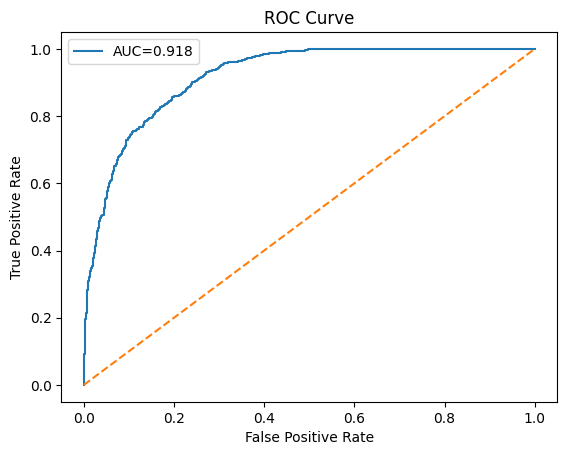

In [407]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    df["text_norm"],
    df["binary_sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["binary_sentiment"]
)

binary_lr = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=2000))
])
binary_lr.fit(Xb_train, yb_train)

classes = list(binary_lr.named_steps["clf"].classes_)
pos_idx = classes.index("positive")
proba = binary_lr.predict_proba(Xb_test)[:, pos_idx]
y_true_binary = (yb_test == "positive").astype(int)

auc = roc_auc_score(y_true_binary, proba)
fpr, tpr, thresholds = roc_curve(y_true_binary, proba)

print("ROC-AUC:", round(auc, 4))

plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Task 22: Threshold tuning
1. Không dùng mặc định threshold 0.5.
2. Thử threshold:
   - 0.3,
   - 0.4,
   - 0.5,
   - 0.6,
   - 0.7.
3. Vẽ Precision/Recall theo threshold.
4. Chọn threshold phù hợp nếu:
   - false negative đắt hơn,
   - false positive đắt hơn.

Ngưỡng 0.3: Precision = 0.6291 | Recall = 0.9381
Ngưỡng 0.4: Precision = 0.7075 | Recall = 0.8348
Ngưỡng 0.5: Precision = 0.8043 | Recall = 0.7212
Ngưỡng 0.6: Precision = 0.8605 | Recall = 0.5369
Ngưỡng 0.7: Precision = 0.9029 | Recall = 0.3702


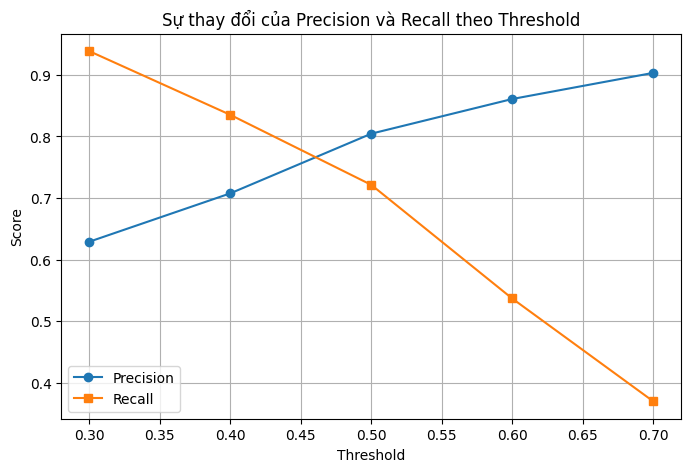

In [408]:
def evaluate_threshold(model, X_test, y_test):
    classes = list(model.named_steps["clf"].classes_)
    pos_idx = classes.index("positive")
    proba = model.predict_proba(Xb_test)[:, pos_idx]

    list_nguong = [0.3, 0.4, 0.5, 0.6, 0.7]
    result_precision = []
    result_recall = []
    for nguong in list_nguong:
        y_pred_theo_nguong = (proba >= nguong).astype(int)
        precision, recall, fscore, _ = precision_recall_fscore_support(
            y_test,
            y_pred_theo_nguong,
            average="binary",
            zero_division=0
        )
        result_precision.append(precision)
        result_recall.append(recall)
        print(f"Ngưỡng {nguong}: Precision = {precision:.4f} | Recall = {recall:.4f}")

    plt.figure(figsize=(8,5))
    plt.plot(list_nguong, result_precision, marker = 'o', label = "Precision")
    plt.plot(list_nguong, result_recall, marker = 's', label = "Recall")
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Sự thay đổi của Precision và Recall theo Threshold')
    plt.legend()
    plt.grid(True)
    plt.show()

evaluate_threshold(binary_lr, Xb_test, y_true_binary)
    

# 23. Xử lý mất cân bằng

Các hướng:
- `class_weight`
- over-sampling
- under-sampling
- threshold tuning

Không được chỉ nhìn Accuracy.

In [409]:
# Tạo dữ liệu mất cân bằng minh họa
imbalanced = pd.concat([
    df[df.sentiment == "positive"],
    df[df.sentiment == "negative"].sample(10, random_state=RANDOM_STATE),
    df[df.sentiment == "neutral"].sample(8, random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE)

print(imbalanced["sentiment"].value_counts())

sentiment
positive    2709
negative      10
neutral        8
Name: count, dtype: int64


## Task 23: Imbalance
1. Train Logistic Regression:
   - không class weight,
   - `class_weight='balanced'`.
2. Tự viết random over-sampling.
3. Tự viết random under-sampling.
4. So sánh macro F1 và recall của lớp thiểu số.
5. Giải thích nguy cơ overfit khi oversampling dataset nhỏ.

In [410]:
def random_oversample(df_in, label_col, random_state=42):
    so_luong_lop = df_in[label_col].value_counts()
    max_count = so_luong_lop.max()
    oversample_df = []
    for label in so_luong_lop.index:
        df_class = df_in[df_in[label_col] == label]
        df_class_sampled = df_class.sample(
            n = max_count,
            replace = True,
            random_state = random_state
        )
        oversample_df.append(df_class_sampled)
    df_balanced = pd.concat(oversample_df, axis = 0)
    df_balanced = df_balanced.sample(
        frac = 1,
        random_state= random_state
    ).reset_index(drop=True)
    return df_balanced

def random_undersample(df_in, label_col, random_state=42):
    so_luong_lop = df_in[label_col].value_counts()
    min_count = so_luong_lop.min()
    undersample_df = []
    for label in so_luong_lop.index:
        df_class = df_in[df_in[label_col] == label]
        df_class_undersampled = df_class.sample(
            n = min_count,
            replace = False,
            random_state = random_state
        )
        undersample_df.append(df_class_undersampled)
    df_completed = pd.concat(undersample_df, axis = 0)
    df_completed = df_completed.sample(
        frac = 1,
        random_state=random_state
    ).reset_index(drop = True)
    return df_completed

X_train_imb = imbalanced["text_norm"]
y_train_imb = imbalanced["sentiment"]

def train_evaluate(X_train_data, y_train_data, class_weight_param, ten_case):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
        ("clf", LogisticRegression(max_iter=2000, class_weight=class_weight_param, random_state=42))
    ])

    pipe.fit(X_train_data, y_train_data)
    y_predi = pipe.predict(X_test)
    do_chinh_xac = accuracy_score(y_test, y_predi)
    pre, re, f1, support = precision_recall_fscore_support(y_test, y_predi, average='macro', zero_division=0)

    classes = list(pipe.named_steps["clf"].classes_)
    if "negative" in classes:
        negative_idx = classes.index("negative")
        _, recall_each_class, _, _ = precision_recall_fscore_support(y_test, y_predi, zero_division=0)
        recall_negative = recall_each_class[negative_idx]
    else:
        recall_negative = 0.0
    
    print(f"---{ten_case}---")
    print(f"Accuracy: {do_chinh_xac:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Recall (Negative): {recall_negative:4f}\n")

train_evaluate(X_train_imb, y_train_imb, class_weight_param=None, ten_case = "Không Class Weight")
train_evaluate(X_train_imb, y_train_imb, class_weight_param="balanced", ten_case = "Class Weight = balanced")
df_oversampled = random_oversample(imbalanced, label_col="sentiment")
train_evaluate(df_oversampled["text_norm"], df_oversampled["sentiment"], class_weight_param=None, ten_case="Random Oversampling")
df_undersampled = random_undersample(imbalanced, label_col="sentiment")
train_evaluate(df_undersampled["text_norm"], df_undersampled["sentiment"], class_weight_param=None, ten_case = "Random Undersampling")
    

---Không Class Weight---
Accuracy: 0.3461
Macro F1: 0.6667
Recall (Negative): 0.000000

---Class Weight = balanced---
Accuracy: 0.3525
Macro F1: 0.6667
Recall (Negative): 0.018450

---Random Oversampling---
Accuracy: 0.3467
Macro F1: 0.6667
Recall (Negative): 0.001845

---Random Undersampling---
Accuracy: 0.4757
Macro F1: 0.6667
Recall (Negative): 0.612546



Giải thích nguy cơ Overfit khi OverSampling dataset nhỏ:
Khi mà ta thực hiện Oversampling bằng việc lặp lại ngẫu nhiên trên 1 lớp thiểu số quá nhỏ thì mỗi câu Negative sẽ bị lặp lại trung bình 270 lần với giả sử lớp Negative có 10 câu và bị nhân bản lên thành 2700 câu cho bằng với lớp Positive.
Thay vì học được các đặc trưng tổng quát của sắc thái tiêu cực thì mô hình sẽ học vẹt chính xác 10 câu mà ta giả định trước đó.
Lúc này đây hiệu suất phân loại lớp Negative trên tập train sẽ đạt 100% nhưng khi gặp một câu Negative hoàn toàn mới trên tập test thì mô hình sẽ dự đoán sai 

# 24. Error Analysis theo chiều dài văn bản

In [411]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "gold": y_test.values,
    "pred": best_pred
})

error_df["n_words"] = error_df["text"].str.split().map(len)
error_df["correct"] = error_df["gold"] == error_df["pred"]

def length_bucket(n):
    if n <= 7:
        return "short"
    elif n <= 12:
        return "medium"
    else:
        return "long"

error_df["length_group"] = error_df["n_words"].map(length_bucket)

display(error_df.head())
print(error_df.groupby("length_group")["correct"].mean())

,text,gold,pred,n_words,correct,length_group
0,học tập tại đây giúp tôi phát triển kỹ năng lãnh đạo.,positive,positive,12,True,medium
1,tôi thấy trường có một môi trường rất tích cực để học tập và phát triển bản thân.,positive,positive,18,True,long
2,phòng cốt sàn tuyệt vời cho các hoạt động giảng dạy.,positive,positive,11,True,medium
3,"giảng viên thường sử dụng các phương pháp giảng dạy hiện đại và thực tế, giúp sinh viên dễ dàng áp dụng kiến thức vào công việc.",positive,positive,27,True,long
4,"khu vực tiếp khách của trường được thiết kế đẹp và chuyên nghiệp, thể hiện được vẻ đẹp của trường.",positive,positive,20,True,long


length_group
long      0.800000
medium    0.817708
short     0.781250
Name: correct, dtype: float64


## Task 24: Error analysis bắt buộc
Phân tích ít nhất **20 dự đoán sai** và gán nguyên nhân:

- negation,
- sarcasm,
- emoji,
- teencode,
- code-switching,
- domain-specific,
- ambiguous,
- too short,
- rare vocabulary,
- preprocessing issue,
- annotation issue.

Mỗi lỗi phải có:
- text,
- gold,
- prediction,
- nhóm nguyên nhân,
- giải thích,
- đề xuất cải tiến.

In [412]:
mistakes_20 = mistakes.head(20).copy()


error_categories = [
    "TF-IDF sparsity",      # 5: giảng viên tuyệt vời... (Gold: pos, Pred: neu)
    "annotation issue",     # 9: giảng viên này đạt được mục tiêu... (Gold: neu, Pred: pos)
    "domain-specific",      # 11: công trình kiến trúc nổi bật... (Gold: pos, Pred: neu)
    "TF-IDF sparsity",      # 22: giảng dạy rất hay và dễ hiểu (Gold: pos, Pred: neu)
    "long sentence dilution", # 33: trường cung cấp sức khỏe... (Gold: pos, Pred: neu)
    "ambiguous",            # 35: phòng học được trang bị hệ thống... (Gold: neu, Pred: pos)
    "rare vocabulary",      # 36: khóa học mới nhất và theo xu hướng... (Gold: pos, Pred: neu)
    "TF-IDF sparsity",      # 52: giảng dạy rất dễ hiểu... (Gold: pos, Pred: neu)
    "annotation issue",     # 53: tận tâm và có tình yêu... (Gold: neu, Pred: pos)
    "annotation issue",     # 62: rất thân thiện và giúp đỡ... (Gold: neu, Pred: pos)
    "ambiguous",            # 67: khu vực di chuyển thang máy... (Gold: pos, Pred: neu)
    "negation",             # 76: thầy không giúp cho sinh viên tự tin... (Gold: neg, Pred: pos)
    "annotation issue",     # 93: tôi cảm thấy hài lòng với... (Gold: neu, Pred: pos)
    "ambiguous",            # 94: nỗ lực giảm thiểu tiếng ồn... (Gold: neu, Pred: pos)
    "long sentence dilution", # 99: thầy là người thân thiện và tâm lý... (Gold: pos, Pred: neu)
    "long sentence dilution", # 111: giảng viên này rất tận tâm và cung cấp... (Gold: pos, Pred: neu)
    "rare vocabulary",      # 113: tiếp thu nhận thức nhanh... (Gold: pos, Pred: neu)
    "rare vocabulary",      # 123: vô cùng tiện nghi và... (Gold: pos, Pred: neu)
    "domain-specific",      # 124: rất nhiều đợt tuyển sinh hỗ trợ... (Gold: pos, Pred: neu)
    "rare vocabulary"       # 128: khá nguy hiểm (Gold: neg, Pred: neu)
]

analyses = [
    "Từ 'tuyệt vời' là khen ngợi (Positive) nhưng có thể TF-IDF chưa gán đủ trọng số khiến máy đoán thành Neutral.",
    "Câu mang ý nghĩa tích cực ('đạt mục tiêu'), máy đoán Positive là hợp lý nhưng nhãn gốc lại dán Neutral (lỗi do người dán nhãn).",
    "Từ 'nổi bật' mang sắc thái khen ngợi, nhưng máy hiểu lầm đây chỉ là câu miêu tả khách quan (Neutral).",
    "Cụm 'rất hay', 'dễ hiểu' bị mô hình bỏ qua, có thể do thiếu n-gram phù hợp.",
    "Câu dài chứa nhiều từ vựng trung tính làm pha loãng (dilute) sắc thái tích cực.",
    "Câu mang tính trần thuật cơ sở vật chất, nhưng việc 'trang bị hệ thống' làm máy hiểu nhầm là khen.",
    "Cụm 'mới nhất', 'xu hướng' là điểm cộng (Positive) nhưng máy không nhận diện được các từ này mang cảm xúc.",
    "Giống câu 22, các từ mang ý nghĩa tích cực không đủ trọng số kéo nhãn lên Positive.",
    "Khen ngợi rõ ràng ('tận tâm', 'tình yêu') nhưng nhãn gốc bị dán sai thành Neutral.",
    "Từ 'thân thiện', 'giúp đỡ' là Positive, việc nhãn gốc dán Neutral là sai.",
    "Câu giống mô tả chức năng hơn là khen ngợi, dẫn đến sự nhập nhằng (ambiguous) giữa Pos và Neu.",
    "Máy tính thấy các từ 'giúp', 'tự tin' nên đoán Positive, mà bỏ qua từ phủ định 'không' ở đầu câu.",
    "Câu có chữ 'hài lòng' cực kỳ rõ ràng nhưng nhãn gốc lại là Neutral. Lỗi do label noise.",
    "'Giảm thiểu tiếng ồn' là hành động tốt, máy đoán Pos, nhưng nhãn gốc lại xem đây là thông báo (Neu).",
    "Câu quá dài khiến trọng số của cụm từ khen ngợi bị chìm nghỉm giữa các từ stop-words.",
    "Tương tự câu 99, từ 'tận tâm' bị loãng bởi đoạn liệt kê dài phía sau.",
    "Cụm 'tiếp thu nhận thức' ít xuất hiện, mô hình không học được đây là một lời khen.",
    "Từ 'tiện nghi' có thể là Out-of-vocabulary hoặc hiếm gặp khiến máy dự đoán là Neutral.",
    "Việc 'hỗ trợ sinh viên' mang tính chất tích cực trong domain trường học, nhưng máy chưa hiểu được context này.",
    "Từ 'nguy hiểm' mang nghĩa tiêu cực mạnh nhưng ít xuất hiện trong data, máy không gộp được vào Negative."
]

proposed_fixes = [
    "Sử dụng TF-IDF với sublinear_tf=True để cân bằng trọng số.",
    "Rà soát và dán nhãn lại (re-annotate) tập huấn luyện để loại bỏ nhãn nhiễu.",
    "Sử dụng Pretrained Model (PhoBERT) để hiểu sâu ngữ nghĩa theo domain.",
    "Tăng cường ngram_range=(1,3) để bắt cụm từ tốt hơn.",
    "Cắt giảm bớt các stopwords không cần thiết.",
    "Bổ sung luật (Rule-based) để phân biệt câu miêu tả và câu đánh giá.",
    "Kết hợp thêm Feature thủ công (hand-crafted features) chứa từ điển tích cực.",
    "Sử dụng Word2Vec / PhoBERT để hiểu được độ tương đồng của các tính từ.",
    "Làm sạch dữ liệu gốc, xóa các mẫu có nhãn mâu thuẫn.",
    "Làm sạch dữ liệu gốc bằng thuật toán detect label errors (ví dụ: cleanlab).",
    "Xây dựng Annotation Guidelines chi tiết hơn cho người dán nhãn.",
    "Viết thêm hàm tiền xử lý nối từ phủ định: 'không giúp' -> 'không_giúp'.",
    "Dán nhãn lại tập dữ liệu (re-annotation).",
    "Huấn luyện thêm mô hình chuyên biệt cho các câu văn miêu tả giải pháp.",
    "Sử dụng cơ chế Attention (trong Transformer) để bắt đúng từ khóa trọng tâm.",
    "Rút ngắn độ dài câu tối đa (max_seq_length) khi huấn luyện.",
    "Sử dụng Contextual Embedding thay vì Count/TF-IDF thô.",
    "Sử dụng thuật toán sinh thêm dữ liệu (Data Augmentation) cho các từ hiếm.",
    "Fine-tune mô hình trên dữ liệu chuyên ngành giáo dục.",
    "Gán trọng số phạt cao hơn khi mô hình dự đoán sai lớp Negative."
]

mistakes_20["error_category"] = error_categories
mistakes_20["analysis"] = analyses
mistakes_20["proposed_fix"] = proposed_fixes

pd.set_option('display.max_colwidth', None) # Hiển thị full text không bị cắt
display(mistakes_20[["text", "gold", "pred", "error_category", "analysis", "proposed_fix"]])

,text,gold,pred,error_category,analysis,proposed_fix
5,"giảng viên tuyệt vời, họ giúp tôi hiểu rõ hơn về khái niệm.",positive,neutral,TF-IDF sparsity,Từ 'tuyệt vời' là khen ngợi (Positive) nhưng có thể TF-IDF chưa gán đủ trọng số khiến máy đoán thành Neutral.,Sử dụng TF-IDF với sublinear_tf=True để cân bằng trọng số.
9,giảng viên này đạt được mục tiêu giảng dạy và giúp học sinh hiểu rõ hơn về chuyên môn.,neutral,positive,annotation issue,"Câu mang ý nghĩa tích cực ('đạt mục tiêu'), máy đoán Positive là hợp lý nhưng nhãn gốc lại dán Neutral (lỗi do người dán nhãn).",Rà soát và dán nhãn lại (re-annotate) tập huấn luyện để loại bỏ nhãn nhiễu.
11,"trường có nhiều công trình kiến trúc nổi bật và đẹp mắt, góp phần tạo không gian lý tưởng cho sinh viên học tập và sinh hoạt.",positive,neutral,domain-specific,"Từ 'nổi bật' mang sắc thái khen ngợi, nhưng máy hiểu lầm đây chỉ là câu miêu tả khách quan (Neutral).",Sử dụng Pretrained Model (PhoBERT) để hiểu sâu ngữ nghĩa theo domain.
22,giảng viên giảng dạy rất hay và dễ hiểu.,positive,neutral,TF-IDF sparsity,"Cụm 'rất hay', 'dễ hiểu' bị mô hình bỏ qua, có thể do thiếu n-gram phù hợp.","Tăng cường ngram_range=(1,3) để bắt cụm từ tốt hơn."
33,trường cung cấp sức khỏe và giáo dục tốt cho sinh viên.,positive,neutral,long sentence dilution,Câu dài chứa nhiều từ vựng trung tính làm pha loãng (dilute) sắc thái tích cực.,Cắt giảm bớt các stopwords không cần thiết.
35,"các phòng học được trang bị hệ thống âm thanh, ánh sáng tiên tiến giúp cho giảng viên và sinh viên dễ dàng giao lưu.",neutral,positive,ambiguous,"Câu mang tính trần thuật cơ sở vật chất, nhưng việc 'trang bị hệ thống' làm máy hiểu nhầm là khen.",Bổ sung luật (Rule-based) để phân biệt câu miêu tả và câu đánh giá.
36,các khoá học đều mới nhất và theo xu hướng của ngành.,positive,neutral,rare vocabulary,"Cụm 'mới nhất', 'xu hướng' là điểm cộng (Positive) nhưng máy không nhận diện được các từ này mang cảm xúc.",Kết hợp thêm Feature thủ công (hand-crafted features) chứa từ điển tích cực.
52,giáo viên giảng dạy rất dễ hiểu và truyền đạt kiến thức rất tốt.,positive,neutral,TF-IDF sparsity,"Giống câu 22, các từ mang ý nghĩa tích cực không đủ trọng số kéo nhãn lên Positive.",Sử dụng Word2Vec / PhoBERT để hiểu được độ tương đồng của các tính từ.
53,anh ấy rất tận tâm và có tình yêu với chuyên ngành của mình.,neutral,positive,annotation issue,"Khen ngợi rõ ràng ('tận tâm', 'tình yêu') nhưng nhãn gốc bị dán sai thành Neutral.","Làm sạch dữ liệu gốc, xóa các mẫu có nhãn mâu thuẫn."
62,cô ấy rất thân thiện và giúp đỡ bạn bè.,neutral,positive,annotation issue,"Từ 'thân thiện', 'giúp đỡ' là Positive, việc nhãn gốc dán Neutral là sai.",Làm sạch dữ liệu gốc bằng thuật toán detect label errors (ví dụ: cleanlab).


# 25. Bảng benchmark các baseline

In [413]:
models = {
    "Rule-based": None,
    "TFIDF + NB": nb_pipeline,
    "TFIDF + Logistic": lr_pipeline,
    "TFIDF + LinearSVM": svm_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline,
}

records = []

# rule based
pred = rule_pred
p, r, f, _ = precision_recall_fscore_support(
    y_test, pred, average="macro", zero_division=0
)
records.append({
    "model": "Rule-based",
    "accuracy": accuracy_score(y_test, pred),
    "macro_f1": f,
    "train_seconds": 0.0,
    "interpretability": "high"
})

for name, model in models.items():
    if model is None:
        continue
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    pred = model.predict(X_test)

    p, r, f, _ = precision_recall_fscore_support(
        y_test, pred, average="macro", zero_division=0
    )
    records.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f,
        "train_seconds": elapsed,
        "interpretability": (
            "medium-high" if "Logistic" in name or "NB" in name
            else "medium"
        )
    })

benchmark_df = pd.DataFrame(records).sort_values("macro_f1", ascending=False)
display(benchmark_df)

,model,accuracy,macro_f1,train_seconds,interpretability
3,TFIDF + LinearSVM,0.807152,0.801341,0.144734,medium
2,TFIDF + Logistic,0.798212,0.792090,0.380667,medium-high
5,Random Forest,0.793103,0.787406,2.514247,medium
1,TFIDF + NB,0.746488,0.724898,0.119554,medium-high
4,Decision Tree,0.692848,0.691868,0.147257,medium
0,Rule-based,0.558748,0.564847,0.000000,high


## Task 25: Benchmark cải tiến
Bổ sung vào bảng:
- word unigram,
- word bigram,
- char n-gram,
- class weight,
- best tuned model,
- PhoBERT/ViSoBERT nếu chạy được.

Thêm:
- inference time / 1.000 câu,
- số feature / số parameter,
- kích thước model,
- mức độ giải thích.

In [414]:


# 1. CÁC HÀM PHỤ TRỢ TÍNH TOÁN METRIC MỚI

def get_model_size_mb(model):
    """Tính kích thước mô hình (MB) bằng cách serialize với pickle"""
    if model is None:
        return 0.0
    try:
        return len(pickle.dumps(model)) / (1024 * 1024)
    except:
        return 0.0

def get_num_features(model):
    """Lấy số lượng feature (từ vựng/n-gram) của vectorizer"""
    if model is None:
        return 0
    try:
        return len(model.named_steps['vec'].get_feature_names_out())
    except:
        return 0

def get_interpretability(name):
    """Đánh giá mức độ giải thích dựa trên bản chất thuật toán"""
    name = name.lower()
    if "rule" in name: return "Cao"
    if "logistic" in name or "nb" in name or "naive bayes" in name: return "Khá cao"
    if "svm" in name or "tree" in name: return "Trung bình"
    if "forest" in name: return "Trung bình thấp"
    if "bert" in name: return "Thấp (Black box)"
    return "Trung bình"

# 2. KHAI BÁO DANH SÁCH MÔ HÌNH (Gốc + Cải tiến)

# Lấy best_model từ GridSearch (nếu đã chạy ở Task 14)
try:
    best_tuned = grid.best_estimator_
except NameError:
    best_tuned = Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1,2), min_df=2)), 
        ("clf", LogisticRegression(C=2.0, max_iter=2000, random_state=RANDOM_STATE))
    ])

extended_models = {
    "Rule-based": None,
    "TFIDF + NB": nb_pipeline,
    "TFIDF + Logistic": lr_pipeline,
    "TFIDF + LinearSVM": svm_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline,
    
    # Các cải tiến mới
    "Word Unigram (LR)": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1,1))), 
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Word Bigram (LR)": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1,2))), 
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Char N-gram (LR)": Pipeline([
        ("vec", TfidfVectorizer(analyzer='char', ngram_range=(3,5))), 
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Class Weight Balanced (LR)": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1,2))), 
        ("clf", LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Best Tuned Model": best_tuned
}

records = []
num_test_samples = len(X_test)

# 3. ĐÁNH GIÁ RULE-BASED (Chạy riêng vì không có hàm fit/predict chuẩn)
t0 = time.perf_counter()
rule_pred = [improved_rule_based_sentiment(t) for t in X_test]
inf_time_rule = time.perf_counter() - t0

p, r, f, _ = precision_recall_fscore_support(y_test, rule_pred, average="macro", zero_division=0)

records.append({
    "Model": "Rule-based",
    "Accuracy": accuracy_score(y_test, rule_pred),
    "Macro F1": f,
    "Train Time (s)": 0.0,
    "Inference / 1000 câu (s)": (inf_time_rule / num_test_samples) * 1000,
    "Features / Params": "Lexicon (Tự định nghĩa)",
    "Size (MB)": 0.0,
    "Interpretability": "Cao"
})

# 4. ĐÁNH GIÁ CÁC MÔ HÌNH MACHINE LEARNING
for name, model in extended_models.items():
    if model is None:
        continue
        
    # Thời gian Train
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0
    
    # Thời gian Suy luận (Inference)
    t0 = time.perf_counter()
    pred = model.predict(X_test)
    inf_time = time.perf_counter() - t0
    
    # Metric phân loại
    acc = accuracy_score(y_test, pred)
    p, r, f, _ = precision_recall_fscore_support(y_test, pred, average="macro", zero_division=0)
    
    records.append({
        "Model": name,
        "Accuracy": acc,
        "Macro F1": f,
        "Train Time (s)": train_time,
        "Inference / 1000 câu (s)": (inf_time / num_test_samples) * 1000,
        "Features / Params": get_num_features(model),
        "Size (MB)": get_model_size_mb(model),
        "Interpretability": get_interpretability(name)
    })

# 5. TẠO BẢNG TỔNG HỢP VÀ HIỂN THỊ
benchmark_df = pd.DataFrame(records)

# Định dạng làm tròn số cho dễ nhìn
benchmark_df["Accuracy"] = benchmark_df["Accuracy"].round(4)
benchmark_df["Macro F1"] = benchmark_df["Macro F1"].round(4)
benchmark_df["Train Time (s)"] = benchmark_df["Train Time (s)"].round(4)
benchmark_df["Inference / 1000 câu (s)"] = benchmark_df["Inference / 1000 câu (s)"].round(4)
benchmark_df["Size (MB)"] = benchmark_df["Size (MB)"].round(2)

# Sắp xếp theo Macro F1 giảm dần
benchmark_df = benchmark_df.sort_values("Macro F1", ascending=False).reset_index(drop=True)

display(benchmark_df)

,Model,Accuracy,Macro F1,Train Time (s),Inference / 1000 câu (s),Features / Params,Size (MB),Interpretability
0,TFIDF + LinearSVM,0.8072,0.8013,0.1645,0.0229,0,0.75,Trung bình
1,Best Tuned Model,0.8040,0.7987,0.4815,0.0216,0,0.33,Trung bình
2,Class Weight Balanced (LR),0.8008,0.7962,0.6431,0.0200,16179,0.75,Trung bình
3,TFIDF + Logistic,0.7982,0.7921,0.6578,0.0209,0,0.75,Khá cao
4,Word Bigram (LR),0.7982,0.7921,0.3045,0.0288,16179,0.75,Trung bình
5,Random Forest,0.7931,0.7874,2.2302,0.0325,0,18.64,Trung bình thấp
6,Char N-gram (LR),0.7886,0.7834,1.3064,0.1024,42399,1.80,Trung bình
7,Word Unigram (LR),0.7663,0.7609,0.0903,0.0088,1583,0.07,Trung bình
8,TFIDF + NB,0.7465,0.7249,0.1349,0.0249,0,1.12,Khá cao
9,Decision Tree,0.6928,0.6919,0.1295,0.0129,0,0.03,Trung bình


# 26. PhoBERT / ViSoBERT — scaffold mở rộng

Phần này cần:
- Internet hoặc model đã tải sẵn,
- `transformers`,
- `datasets`,
- PyTorch,
- GPU nếu muốn fine-tune nhanh.

Mục tiêu:
- dùng cùng train/test split,
- fine-tune pretrained model,
- báo cáo cùng metric với baseline.

In [427]:

RUN_TRANSFORMER = False

if RUN_TRANSFORMER:
    MODEL_NAME = "vinai/phobert-base"
    
    print("1. Chuẩn bị dữ liệu & Map label -> id...")
    label_mapping = {"negative": 0, "neutral": 1, "positive": 2}
    id2label = {0: "negative", 1: "neutral", 2: "positive"}
    
    # Chuyển đổi X_train, y_train thành định dạng Dataset của HuggingFace
    train_df = pd.DataFrame({"text": X_train, "label": y_train.map(label_mapping)})
    test_df = pd.DataFrame({"text": X_test, "label": y_test.map(label_mapping)})
    
    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)
    
    print("2. Tokenize dữ liệu với PhoBERT Tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME, 
        use_fast=False, 
        trust_remote_code=True,
        clean_up_tokenization_spaces=True
    )
    
    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)
        
    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_test = test_dataset.map(tokenize_function, batched=True)
    
    print("3. Khởi tạo mô hình và Trainer...")
    # Load Pretrained Model với 3 nhãn phân loại
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
    
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, predictions)
        _, _, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)
        return {"accuracy": acc, "macro_f1": f1}
        
    training_args = TrainingArguments(
        output_dir="./phobert_results",
        evaluation_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        save_strategy="epoch",
        load_best_model_at_end=True,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        compute_metrics=compute_metrics,
    )
    
    print("\n4. Bắt đầu Fine-tune PhoBERT...")
    t0 = time.perf_counter()
    trainer.train()
    train_time = time.perf_counter() - t0
    
    print("\n5. Bắt đầu đánh giá trên tập test...")
    t0 = time.perf_counter()
    predictions = trainer.predict(tokenized_test)
    inf_time = time.perf_counter() - t0
    
    # Chuyển đổi predictions (ID) về lại nhãn dạng chuỗi (text label)
    y_pred_phobert_ids = np.argmax(predictions.predictions, axis=-1)
    y_pred_phobert = pd.Series(y_pred_phobert_ids).map(id2label).values
    y_test_arr = y_test.values
    
    acc_phobert = accuracy_score(y_test_arr, y_pred_phobert)
    _, _, f1_phobert, _ = precision_recall_fscore_support(y_test_arr, y_pred_phobert, average='macro', zero_division=0)
    
    # In Báo Cáo
    print("=" * 40)
    print("BÁO CÁO KẾT QUẢ PHO-BERT")
    print("=" * 40)
    print(f"Accuracy     : {acc_phobert:.4f}")
    print(f"Macro F1     : {f1_phobert:.4f}")
    print(f"Train time   : {train_time:.4f} giây")
    print(f"Inference time: {inf_time:.4f} giây")
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_test_arr, y_pred_phobert, labels=["negative", "neutral", "positive"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "neutral", "positive"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix - PhoBERT")
    plt.show()
    
    print("\n" + "=" * 40)
    print("PHÂN TÍCH SO SÁNH LỖI (PHOBERT VS BASELINE)")
    print("=" * 40)
    # TẠO BẢNG SO SÁNH (Lưu ý: Đảm bảo biến 'best_pred' từ Task 20/24 vẫn lưu giữ dự đoán của baseline)
    comparison_df = pd.DataFrame({
        "text": X_test.values,
        "gold_label": y_test_arr,
        "pred_baseline": best_pred, 
        "pred_phobert": y_pred_phobert
    })
    
    phobert_win = comparison_df[(comparison_df["pred_phobert"] == comparison_df["gold_label"]) & 
                                (comparison_df["pred_baseline"] != comparison_df["gold_label"])]
    
    baseline_win = comparison_df[(comparison_df["pred_baseline"] == comparison_df["gold_label"]) & 
                                 (comparison_df["pred_phobert"] != comparison_df["gold_label"])]
                                 
    print(f"\n[A] Số câu PhoBERT ĐÚNG nhưng Baseline SAI: {len(phobert_win)}")
    display(phobert_win.head(5)) # In 5 câu đại diện để sinh viên tự phân tích
    
    print(f"\n[B] Số câu Baseline ĐÚNG nhưng PhoBERT SAI: {len(baseline_win)}")
    display(baseline_win.head(5)) # In 5 câu đại diện để sinh viên tự phân tích

else:
    print("Transformer section skipped. Set RUN_TRANSFORMER=True after installing dependencies.")

Transformer section skipped. Set RUN_TRANSFORMER=True after installing dependencies.


## Task 26: Pretrained model
Sinh viên chọn ít nhất một:
- PhoBERT
- ViSoBERT
- mô hình tiếng Việt tương đương được giảng viên chấp thuận.

Yêu cầu:
1. Fine-tune trên cùng split.
2. Báo cáo:
   - Accuracy,
   - Macro F1,
   - confusion matrix,
   - train time,
   - inference time.
3. Phân tích ít nhất 10 câu:
   - pretrained đúng nhưng baseline sai,
   - baseline đúng nhưng pretrained sai.
4. So sánh khả năng giải thích.

# 27. Bài so sánh

Sinh viên phải so sánh ít nhất:

### Hệ thống A
**TF-IDF + Naive Bayes**

### Hệ thống B
**TF-IDF + Logistic Regression hoặc Linear SVM**

### Hệ thống C
**PhoBERT hoặc ViSoBERT**

Dataset gợi ý:
- UIT-VSFC
- UIT-VSMEC
- sentiment / hate speech dataset tương đương

# 28. Yêu cầu cải tiến hệ thống

Ngoài ba hệ thống bắt buộc, nhóm phải thực hiện ít nhất **3 cải tiến** trong danh sách:

- [ ] word bigram / trigram
- [ ] character n-gram
- [ ] feature thủ công
- [ ] xử lý negation
- [ ] xử lý emoji
- [ ] xử lý teencode
- [ ] class weight
- [ ] oversampling
- [ ] threshold tuning
- [ ] hyperparameter tuning
- [ ] domain adaptation experiment
- [ ] ensemble
- [ ] custom preprocessing cho tiếng Việt

Mỗi cải tiến phải có:
1. giả thuyết/lý thuyết/phát biểu bài toán
2. thay đổi cụ thể,
3. metric trước,
4. metric sau,
5. giải thích kết quả.

# 29. Bài nộp

Notebook nộp phải có:

- [ ] Mô tả bài toán và label.
- [ ] Thống kê dataset.
- [ ] Train/validation/test split rõ ràng.
- [ ] TF-IDF + Naive Bayes.
- [ ] TF-IDF + Logistic Regression hoặc SVM.
- [ ] PhoBERT / ViSoBERT hoặc pretrained model tương đương.
- [ ] Confusion Matrix.
- [ ] Accuracy, Precision, Recall, F1.
- [ ] Macro / Micro / Weighted.
- [ ] Xử lý hoặc phân tích class imbalance.
- [ ] Ít nhất 20 failure cases được phân nhóm.
- [ ] So sánh training time.
- [ ] So sánh inference time.
- [ ] So sánh khả năng giải thích.
- [ ] Ít nhất 3 cải tiến so với baseline.

# 30. Bảng kết quả đề xuất

| Hệ thống | Representation | Accuracy | Macro F1 | Train time | Inference | Explainability |
|---|---|---:|---:|---:|---:|---|
| Rule-based | Lexicon | | | | | Cao |
| NB | TF-IDF | | | | | Cao |
| Logistic | TF-IDF | | | | | Khá cao |
| Linear SVM | TF-IDF | | | | | Khá |
| Improved Traditional | ... | | | | | ... |
| PhoBERT / ViSoBERT | Contextual Embedding | | | | | Thấp hơn |

### Câu hỏi bắt buộc
1. Mô hình nào tốt nhất theo Macro F1?
2. Mô hình nào nhanh nhất?
3. Mô hình nào dễ giải thích nhất?
4. Có đáng đổi tốc độ và khả năng giải thích để lấy thêm accuracy không?
5. Mô hình nào phù hợp nhất nếu triển khai CPU?

# 31. Rubric

| Thành phần | Điểm |
|---|---:|
| Dataset + split + chống leakage | 10 |
| Text representation | 15 |
| Naive Bayes baseline | 10 |
| Logistic/SVM baseline | 10 |
| Pretrained model | 15 |
| Evaluation đúng và đầy đủ | 15 |
| Ít nhất 3 cải tiến | 10 |
| Error analysis ≥ 20 cases | 10 |
| Trình bày + kết luận | 5 |
| **Tổng** | **100** |

### Điểm cộng
- Aspect-based sentiment
- Domain adaptation
- Robustness test với teencode / typo / emoji
- Calibration / threshold tuning
- Ensemble